# **ME630 -Assignment 1 - Problem Statement 8**

**Name:** Meghaj Nandumar Barhate  
**Programme:** M.Tech. in Fluid and Thermal Sciences  
**Roll Number:** 261050047 

---

> # Hollow cylinder with an insulated bore under one-sided flux

Consider a hollow cylinder (tube) of inner radius $R_i$ and outer radius $R_o$. One half of its outer circumference is exposed to a solar-type heat flux, while the entire outer circumference is cooled by convection. The inner bore is insulated.

### Governing Equation

For steady-state conduction with no internal heat generation,

$$
\frac{1}{r}\frac{\partial}{\partial r}
\left(
r\frac{\partial T}{\partial r}
\right)
+
\frac{1}{r^2}\frac{\partial^2 T}{\partial \theta^2}
=0,
\qquad
R_i \leq r \leq R_o,
\quad
0 \leq \theta < 2\pi.
$$

### Boundary Conditions

At the insulated inner surface,

$$
\left.
\frac{\partial T}{\partial r}
\right|_{r=R_i}
=0.
$$

At the outer surface,

$$
-k
\left.
\frac{\partial T}{\partial r}
\right|_{r=R_o}
=
h\left(T(R_o,\theta)-T_\infty\right)-q''(\theta).
$$

The applied circumferential heat flux is

$$
q''(\theta)=
\begin{cases}
q_0''\sin\theta, & 0<\theta<\pi,\\
0, & \pi<\theta<2\pi.
\end{cases}
$$

### Data

$$
R_i = 0.02\ \text{m},
\qquad
R_o = 0.05\ \text{m},
$$

$$
k = 20\ \text{W/(m K)},
\qquad
h = 15\ \text{W/(m}^2\text{ K)},
$$

$$
T_\infty = 25^\circ\text{C},
\qquad
q_0'' = 1200\ \text{W/m}^2.
$$

---

## Analytical Solution

Because the bore at $r=R_i$ is insulated, each harmonic must independently satisfy the zero-gradient condition at $R_i$. Define

$$
f_n(r)=r^n+R_i^{2n}r^{-n},
$$

which automatically satisfies

$$
f_n'(R_i)=0
$$

for every $n$.

Express the applied heat flux as a Fourier series,

$$
q''(\theta)
=
a_0+\sum_{n\geq 1}
\left(
a_n\cos n\theta+b_n\sin n\theta
\right).
$$

For the half-wave-rectified sine distribution,

$$
a_0=\frac{q_0''}{\pi},
\qquad
b_1=\frac{q_0''}{2},
$$

and

$$
a_{2m}
=
-\frac{2q_0''}{\pi(4m^2-1)},
\qquad
m=1,2,3,\ldots
$$

with all other Fourier coefficients equal to zero.

The resulting temperature distribution satisfying both radial boundary conditions is

$$
T(r,\theta)
=
T_\infty
+
\frac{a_0}{h}
+
\frac{b_1f_1(r)}
{hf_1(R_o)+kf_1'(R_o)}
\sin\theta
+
\sum_{m=1}^{\infty}
\frac{a_{2m}f_{2m}(r)}
{hf_{2m}(R_o)+kf_{2m}'(R_o)}
\cos(2m\theta).
$$

### Limiting Check

As $R_i\rightarrow 0$,

$$
f_n(r)\rightarrow r^n,
$$

$$
f_n(R_o)\rightarrow R_o^n,
$$

and

$$
f_n'(R_o)\rightarrow nR_o^{n-1}.
$$

Hence, the hollow-cylinder solution approaches the corresponding solid-cylinder result.

---

> ## Tasks

### (a) Boundary-Condition Matching

Derive the boundary-condition matching that produces $f_n(r)$ and the coefficient formula given above. Show the algebra that leads from the general radial solution involving $r^n$ and $r^{-n}$ to the stated result.

### (b) Finite-Difference Discretization

Discretize the annulus on a grid with

$$
\Delta r=\frac{R_o-R_i}{M},
\qquad
\Delta\theta=\frac{2\pi}{N},
$$

with periodicity in $\theta$.

No pole treatment is required because the origin is not part of the computational domain. Derive the discretized insulated-bore boundary condition at

$$
r=R_i,
$$

using either a ghost-node formulation or a one-sided finite-difference approximation.

### (c) Numerical Solution and Comparison

Solve the linear system

$$
[A]\{T\}=\{b\}
$$

using:

- a direct method,
- Gauss-Seidel iteration,
- SOR iteration.

Compare the numerical outer-surface temperature $T(R_o,\theta)$ with the analytical-series solution at

$$
\theta=0^\circ,\ 90^\circ,\ 180^\circ,\ 270^\circ.
$$

Also determine the locations and temperatures of the hottest and coldest points on the outer surface.

### (d) Energy-Conservation and Boundary-Condition Verification

Verify overall energy conservation by evaluating

$$
\oint_0^{2\pi}
\left[
q''(\theta)
-
h\left(T(R_o,\theta)-T_\infty\right)
\right]
R_o\,d\theta
\approx 0.
$$

Separately confirm that the radial heat flux at the insulated inner surface,

$$
r=R_i,
$$

is numerically zero everywhere. This serves as a verification of the insulated-bore boundary-condition implementation.

### (e) Limiting-Case Validation

Re-run the annulus solver with the inner radius reduced to

$$
R_i=0.001R_o,
$$

so that the geometry approaches a solid cylinder.

Using the same values of $R_o$, $k$, $h$, $T_\infty$, and $q_0''$, verify that the computed temperature field $T(r,\theta)$ converges to the corresponding solid-cylinder analytical solution.

Report the residual difference as

$$
R_i\rightarrow 0.
$$

---


### Library Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import lu_factor, lu_solve
import os
import time as t
%pip install -qq numpy scipy matplotlib psutil ipympl
%matplotlib widget
%matplotlib widget
from pathlib import Path
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Arc

Note: you may need to restart the kernel to use updated packages.


> ## **Problem Diagram**

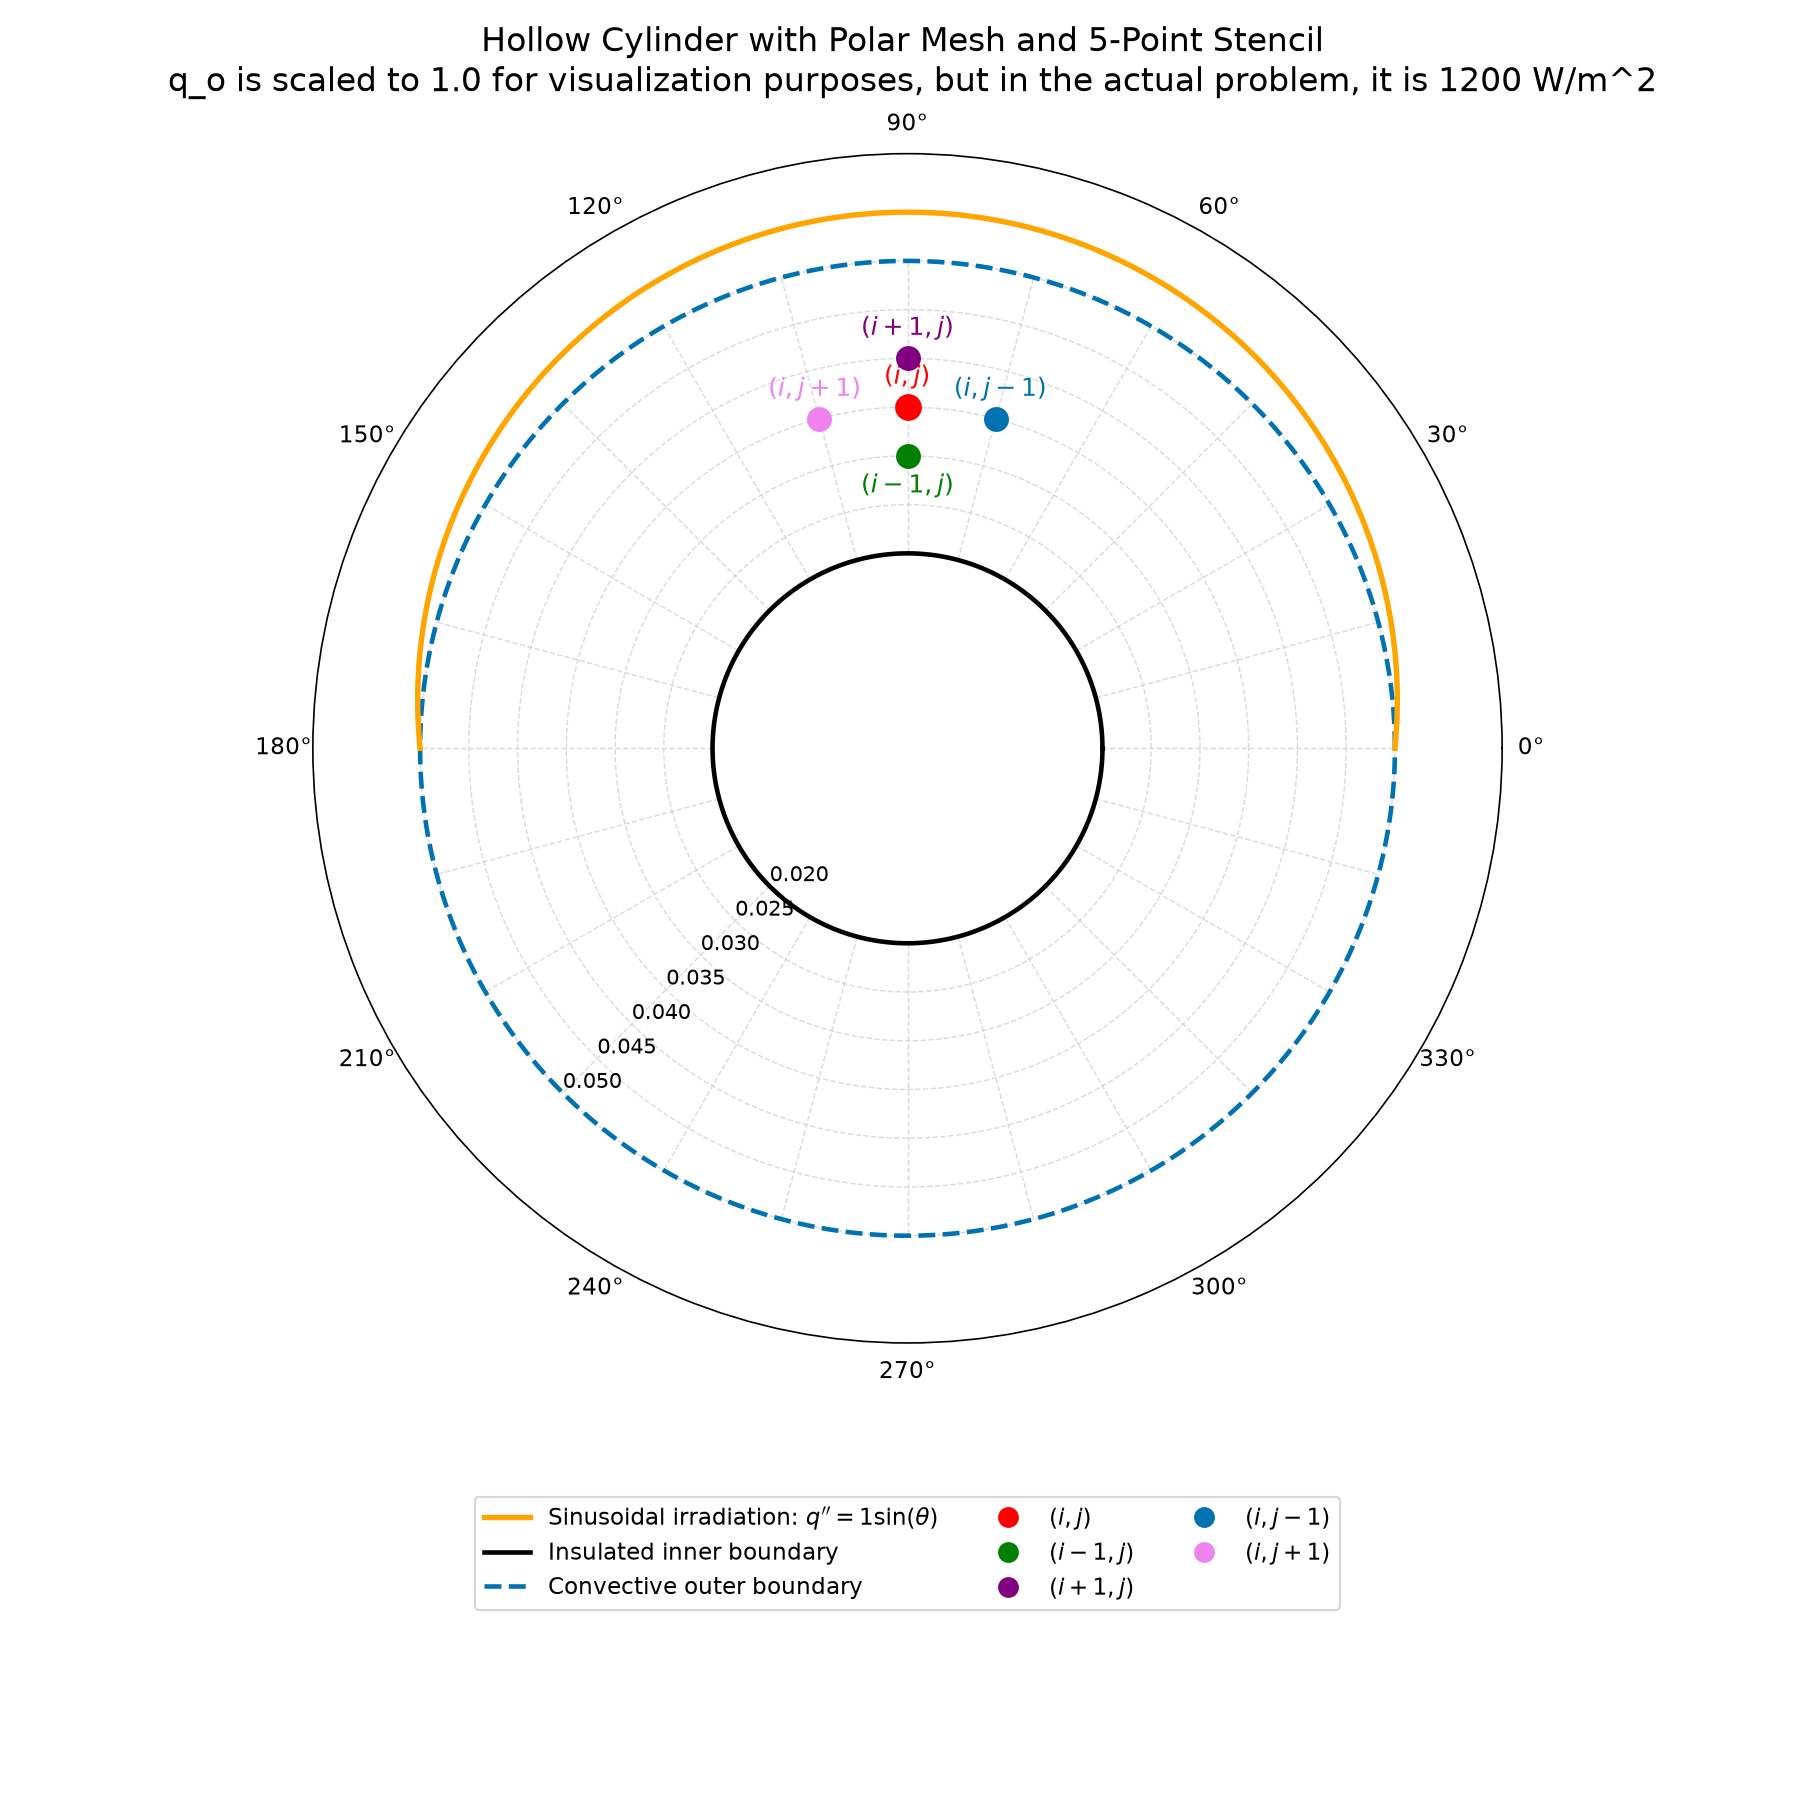

In [2]:
from matplotlib.lines import Line2D

def PlotProblemGeometry(innerRadius, outerRadius, deltaR):
    fig, ax = plt.subplots(figsize=(12, 12), dpi=150, subplot_kw={'projection': 'polar'})
    latexBlue = '#0072B2'
    meshColor = 'lightgrey'
    theta = np.linspace(0, 2 * np.pi, 1000)

    # Polar mesh
    radiusValues = np.arange(innerRadius, outerRadius + 0.5 * deltaR, deltaR)
    for radius in radiusValues:
        ax.plot(theta, np.full_like(theta, radius), linestyle='--', color=meshColor, linewidth=0.7, alpha=0.8, zorder=0)
    deltaTheta = np.pi / 12
    thetaValues = np.arange(0, 2 * np.pi, deltaTheta)
    for angle in thetaValues:
        ax.plot([angle, angle], [innerRadius, outerRadius], linestyle='--', color=meshColor, linewidth=0.7, alpha=0.8, zorder=0)

    # Boundary conditions
    ax.plot(theta, np.full_like(theta, innerRadius), color='black', linewidth=2.2, zorder=2)
    ax.plot(theta, np.full_like(theta, outerRadius), color=latexBlue, linestyle='--', linewidth=2.2, zorder=2)
    radiationTheta = np.linspace(0, np.pi, 500)
    radiationProfile = 1.0 * np.sin(radiationTheta)
    radiationDisplayScale = deltaR
    radiationRadius = outerRadius + radiationDisplayScale * radiationProfile
    ax.plot(radiationTheta, radiationRadius, color='orange', linewidth=2.6, zorder=3)

    # Five-point dependency map
    pointRadius = innerRadius + 3 * deltaR
    pointTheta = np.pi / 2
    stencilPoints = {
        "(i,j)": (pointTheta, pointRadius),
        "(i,j-1)": (pointTheta - deltaTheta, pointRadius),
        "(i,j+1)": (pointTheta + deltaTheta, pointRadius),
        "(i-1,j)": (pointTheta, pointRadius - deltaR),
        "(i+1,j)": (pointTheta, pointRadius + deltaR)
    }

    ax.scatter(*stencilPoints["(i,j)"], s=140, color='red', zorder=5)
    ax.scatter(*stencilPoints["(i,j-1)"], s=120, color=latexBlue, zorder=5)
    ax.scatter(*stencilPoints["(i,j+1)"], s=120, color='violet', zorder=5)
    ax.scatter(*stencilPoints["(i-1,j)"], s=120, color='green', zorder=5)
    ax.scatter(*stencilPoints["(i+1,j)"], s=120, color='purple', zorder=5)

    textOffset = 0.0018
    ax.text(pointTheta, pointRadius + textOffset, r'$(i,j)$', color='red', fontsize=12, ha='center', va='bottom')
    ax.text(pointTheta - deltaTheta, pointRadius + textOffset, r'$(i,j-1)$', color=latexBlue, fontsize=12, ha='center', va='bottom')
    ax.text(pointTheta + deltaTheta, pointRadius + textOffset, r'$(i,j+1)$', color='violet', fontsize=12, ha='center', va='bottom')
    ax.text(pointTheta, pointRadius - deltaR - textOffset, r'$(i-1,j)$', color='green', fontsize=12, ha='center', va='top')
    ax.text(pointTheta, pointRadius + deltaR + textOffset, r'$(i+1,j)$', color='purple', fontsize=12, ha='center', va='bottom')

    # Polar axes
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    angleTicks = np.arange(0, 360, 30)
    ax.set_thetagrids(angleTicks, fontsize=11)

    radialTicks = np.arange(innerRadius, outerRadius + 0.5 * deltaR, deltaR)
    ax.set_yticks(radialTicks)
    ax.set_yticklabels([f'{radius:.3f}' for radius in radialTicks], fontsize=10)
    ax.set_rlabel_position(225)
    ax.set_ylim(0, outerRadius + 2.2 * deltaR)
    ax.grid(False)

    legendHandles = [
        Line2D([0], [0], color='orange', linewidth=2.6, label=r'Sinusoidal irradiation: $q^{\prime\prime}=1\sin(\theta)$'),
        Line2D([0], [0], color='black', linewidth=2.2, label='Insulated inner boundary'),
        Line2D([0], [0], color=latexBlue, linestyle='--', linewidth=2.2, label='Convective outer boundary'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='red', markeredgecolor='red', markersize=9, label=r'$(i,j)$'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='green', markeredgecolor='green', markersize=9, label=r'$(i-1,j)$'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='purple', markeredgecolor='purple', markersize=9, label=r'$(i+1,j)$'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=latexBlue, markeredgecolor=latexBlue, markersize=9, label=r'$(i,j-1)$'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='violet', markeredgecolor='violet', markersize=9, label=r'$(i,j+1)$')
    ]

    ax.legend(handles=legendHandles, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=11, frameon=True)
    ax.set_title('Hollow Cylinder with Polar Mesh and 5-Point Stencil \n q_o is scaled to 1.0 for visualization purposes, but in the actual problem, it is 1200 W/m^2', fontsize=16, pad=30)

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

innerRadius = 0.02
outerRadius = 0.05
deltaR = 0.005

PlotProblemGeometry(innerRadius, outerRadius, deltaR)

> ## **Problem Value Definitions**

In [3]:
innerRadius = 0.02
innerRadiusLimitting = 0.002
outerRadius = 0.05
thermalConductivity = 20
convectionCoefficient = 15
ambientTemperature = 25
heatFluxAmplitude = 1200

### Analytical Solution Plot

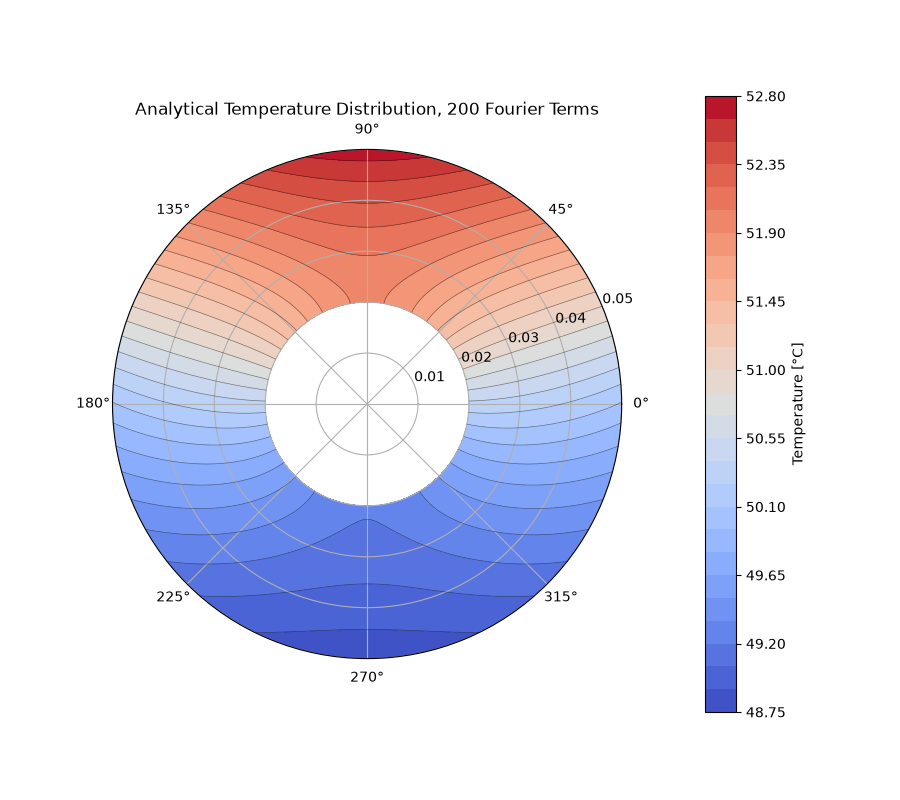

array([[50.36058365, 50.37245304, 50.38435495, ..., 50.33694604,
        50.34874768, 50.36058365],
       [50.36057342, 50.3724431 , 50.38434529, ..., 50.33693527,
        50.34873718, 50.36057342],
       [50.36054302, 50.37241352, 50.38431655, ..., 50.33690325,
        50.34870597, 50.36054302],
       ...,
       [50.09108623, 50.10837808, 50.12598292, ..., 50.05751247,
        50.07414155, 50.09108623],
       [50.08856577, 50.10590796, 50.12357565, ..., 50.05496903,
        50.07160335, 50.08856577],
       [50.0860129 , 50.10341293, 50.12114802, ..., 50.0524051 ,
        50.06904016, 50.0860129 ]], shape=(220, 721))

In [4]:
def RadialRatio(radius, eigenModeNumber, innerRadius, outerRadius, convectionCoefficient, thermalConductivity):
    radiusRatio = radius / outerRadius
    innerRadiusRatio = innerRadius / outerRadius
    innerRadiusPower = innerRadiusRatio ** (2 * eigenModeNumber)
    radialNumerator = radiusRatio ** eigenModeNumber + innerRadiusPower * radiusRatio ** (-eigenModeNumber)
    radialDenominator = convectionCoefficient * (1 + innerRadiusPower) + (thermalConductivity * eigenModeNumber / outerRadius) * (1 - innerRadiusPower)
    return radialNumerator / radialDenominator


def AnalyticalTemperature(radius, theta, innerRadius, outerRadius, thermalConductivity, convectionCoefficient, ambientTemperature, heatFluxAmplitude, numberOfTerms):
    temperature = np.full_like(radius, ambientTemperature + heatFluxAmplitude / (np.pi * convectionCoefficient), dtype=float)
    temperature += (heatFluxAmplitude / 2) * RadialRatio(radius, 1, innerRadius, outerRadius, convectionCoefficient, thermalConductivity) * np.sin(theta)
    for m in range(1, numberOfTerms + 1):
        eigenModeNumber = 2 * m
        eigenModeCoefficient = -2 * heatFluxAmplitude / (np.pi * (4 * m ** 2 - 1))
        temperature += eigenModeCoefficient * RadialRatio(radius, eigenModeNumber, innerRadius, outerRadius, convectionCoefficient, thermalConductivity) * np.cos(eigenModeNumber * theta)
    return temperature


def PlotAnalyticalTemperatureContour(innerRadius, outerRadius, thermalConductivity, convectionCoefficient, ambientTemperature, heatFluxAmplitude, numberOfTerms=50):
    radiusValues = np.linspace(innerRadius, outerRadius, 220)
    thetaValues = np.linspace(0, 2 * np.pi, 721)
    thetaMesh, radiusMesh = np.meshgrid(thetaValues, radiusValues)
    temperatureField = AnalyticalTemperature(radiusMesh, thetaMesh, innerRadius, outerRadius, thermalConductivity, convectionCoefficient, ambientTemperature, heatFluxAmplitude, numberOfTerms)
    fig, ax = plt.subplots(figsize=(9, 8), subplot_kw={'projection': 'polar'})
    temperatureContour = ax.contourf(thetaMesh, radiusMesh, temperatureField, levels=30, cmap='coolwarm')
    ax.contour(thetaMesh, radiusMesh, temperatureField, levels=30, colors='black', linewidths=0.45, alpha=0.5)
    fig.colorbar(temperatureContour, ax=ax, pad=0.12, label='Temperature [°C]')
    ax.set_title(f'Analytical Temperature Distribution, {numberOfTerms} Fourier Terms')
    ax.set_ylim(0, outerRadius)
    ax.grid(True)
    plt.show()
    return temperatureField

PlotAnalyticalTemperatureContour(innerRadius, outerRadius, thermalConductivity, convectionCoefficient, ambientTemperature, heatFluxAmplitude, numberOfTerms=200)

> ## **Mesh generation And Finite Difference Discretization**

In [5]:
boundaryConditions = ['None', 'Neumann', 'ConvectionRobin', 'RadiationConvectionRobin']

class ColorMap:
    def __init__(self, boundaryConditions):
        self.boundaryConditions = boundaryConditions
        self.colorMap = {
            'Internal': 'lightgrey',
            'Neumann': 'red',
            'ConvectionRobin': 'green',
            'RadiationConvectionRobin': 'purple'
        }

    def getColor(self, boundaryType):
        return self.colorMap.get(boundaryType, 'lightgrey')

colorMap = ColorMap(boundaryConditions)

class PointMapper:
    def __init__(self, radialIndex, angularIndex, outerRadialIndex, innerRadialIndex, cwAngularIndex, ccwAngularIndex, unifiedIndex):
        self.unifiedIndex = unifiedIndex
        self.radialIndex = radialIndex
        self.angularIndex = angularIndex
        self.outerRadialIndex = outerRadialIndex
        self.innerRadialIndex = innerRadialIndex
        self.cwAngularIndex = cwAngularIndex
        self.ccwAngularIndex = ccwAngularIndex
        self.prevRadialUnifiedIndex = None
        self.nextRadialUnifiedIndex = None
        self.prevAzimuthalUnifiedIndex = None
        self.nextAzimuthalUnifiedIndex = None
        self.pointCoefficient = None
        self.nextRadialUnifiedCoefficient = None
        self.prevRadialUnifiedCoefficient = None
        self.nextAzimuthalUnifiedCoefficient = None
        self.prevAzimuthalUnifiedCoefficient = None
        self.isBoundary = False
        self.boundaryType = None
    
class ConcentricMesh:
    def __init__(self, innerRadius, outerRadius, radialSteps, angularSteps):
        self.innerRadius = innerRadius
        self.outerRadius = outerRadius
        self.radialSteps = radialSteps
        self.angularSteps = angularSteps
        self.deltaR = (outerRadius - innerRadius) / radialSteps
        self.deltaTheta = 2 * np.pi / angularSteps
        self.nRadii = np.linspace(innerRadius, outerRadius, radialSteps + 1)
        self.nAngles = np.linspace(0, 2 * np.pi, angularSteps, endpoint=False)
        self.numElements = (radialSteps + 1) * angularSteps
        self.pointMap = {}

def ComputePointMapping(mesh):
    prevRadialIndex = None
    nextRadialIndex = None
    prevAzimuthalIndex = None
    nextAzimuthalIndex = None
    currentUnifiedIndex = None
    nextRadialUnifiedIndex = None
    prevRadialUnifiedIndex = None
    nextAzimuthalUnifiedIndex = None
    prevAzimuthalUnifiedIndex = None
    currentBoundaryType = None
    currentBoundaryBool = False

    for radialIndex in range(0, mesh.radialSteps + 1):
        for azimuthalIndex in range(0, mesh.angularSteps):

            currentUnifiedIndex = azimuthalIndex + ((mesh.angularSteps) * radialIndex)
            # print(f"Current Unified Index: {currentUnifiedIndex}, Radial Index: {radialIndex}, Azimuthal Index: {azimuthalIndex}")

            if currentUnifiedIndex < mesh.angularSteps:
                prevRadialIndex = None
                nextRadialIndex = radialIndex + 1
                currentBoundaryType = 'Neumann'
                currentBoundaryBool = True
            elif (currentUnifiedIndex >= mesh.numElements - mesh.angularSteps):
                nextRadialIndex = None
                prevRadialIndex = radialIndex - 1
                currentBoundaryBool = True
                if azimuthalIndex > 0 and azimuthalIndex < (int(mesh.angularSteps/2)):
                    currentBoundaryType = 'RadiationConvectionRobin'
                else:
                    currentBoundaryType = 'ConvectionRobin'
            else:
                nextRadialIndex = radialIndex + 1
                prevRadialIndex = radialIndex - 1
                currentBoundaryType = 'None'
                currentBoundaryBool = False

            #****** if (azimuthalIndex % mesh.angularSteps == 11):
            if (azimuthalIndex % mesh.angularSteps == mesh.angularSteps - 1):
                nextAzimuthalIndex = 0
                prevAzimuthalIndex = azimuthalIndex - 1
            elif (azimuthalIndex % mesh.angularSteps == 0):
                nextAzimuthalIndex = azimuthalIndex + 1
                prevAzimuthalIndex = mesh.angularSteps - 1
            else:
                nextAzimuthalIndex = azimuthalIndex + 1
                prevAzimuthalIndex = azimuthalIndex - 1

            mesh.pointMap[currentUnifiedIndex] = PointMapper(radialIndex, azimuthalIndex, nextRadialIndex, prevRadialIndex, nextAzimuthalIndex, prevAzimuthalIndex, currentUnifiedIndex)

            #****** if(prevRadialIndex is not None) and (nextRadialIndex is not None):
            if(nextRadialIndex is not None):
                nextRadialUnifiedIndex = nextRadialIndex * mesh.angularSteps + azimuthalIndex
            else:
                nextRadialUnifiedIndex = None

            if(prevRadialIndex is not None):
                prevRadialUnifiedIndex = prevRadialIndex * mesh.angularSteps + azimuthalIndex
            else:
                prevRadialUnifiedIndex = None

            #******     nextAzimuthalUnifiedIndex = radialIndex * mesh.angularSteps + nextAzimuthalIndex
            nextAzimuthalUnifiedIndex = radialIndex * mesh.angularSteps + nextAzimuthalIndex
            #******     prevAzimuthalUnifiedIndex = radialIndex * mesh.angularSteps + prevAzimuthalIndex
            prevAzimuthalUnifiedIndex = radialIndex * mesh.angularSteps + prevAzimuthalIndex

            mesh.pointMap[currentUnifiedIndex].nextRadialUnifiedIndex = nextRadialUnifiedIndex
            mesh.pointMap[currentUnifiedIndex].prevRadialUnifiedIndex = prevRadialUnifiedIndex
            mesh.pointMap[currentUnifiedIndex].nextAzimuthalUnifiedIndex = nextAzimuthalUnifiedIndex
            mesh.pointMap[currentUnifiedIndex].prevAzimuthalUnifiedIndex = prevAzimuthalUnifiedIndex
            mesh.pointMap[currentUnifiedIndex].isBoundary = currentBoundaryBool
            mesh.pointMap[currentUnifiedIndex].boundaryType = currentBoundaryType
            #print all data in Line
            print(f"Unified Index: {currentUnifiedIndex}, Radial: {radialIndex}, Azimuthal: {azimuthalIndex}, Next Radial: {nextRadialIndex}, Prev Radial: {prevRadialIndex}, Next Azimuthal: {nextAzimuthalIndex}, Prev Azimuthal: {prevAzimuthalIndex}, Is Boundary: {currentBoundaryBool}, Boundary Type: {currentBoundaryType}")

mesh1 = ConcentricMesh(innerRadius, outerRadius, radialSteps = 3, angularSteps=12)
print(mesh1.numElements)
ComputePointMapping(mesh1)


48
Unified Index: 0, Radial: 0, Azimuthal: 0, Next Radial: 1, Prev Radial: None, Next Azimuthal: 1, Prev Azimuthal: 11, Is Boundary: True, Boundary Type: Neumann
Unified Index: 1, Radial: 0, Azimuthal: 1, Next Radial: 1, Prev Radial: None, Next Azimuthal: 2, Prev Azimuthal: 0, Is Boundary: True, Boundary Type: Neumann
Unified Index: 2, Radial: 0, Azimuthal: 2, Next Radial: 1, Prev Radial: None, Next Azimuthal: 3, Prev Azimuthal: 1, Is Boundary: True, Boundary Type: Neumann
Unified Index: 3, Radial: 0, Azimuthal: 3, Next Radial: 1, Prev Radial: None, Next Azimuthal: 4, Prev Azimuthal: 2, Is Boundary: True, Boundary Type: Neumann
Unified Index: 4, Radial: 0, Azimuthal: 4, Next Radial: 1, Prev Radial: None, Next Azimuthal: 5, Prev Azimuthal: 3, Is Boundary: True, Boundary Type: Neumann
Unified Index: 5, Radial: 0, Azimuthal: 5, Next Radial: 1, Prev Radial: None, Next Azimuthal: 6, Prev Azimuthal: 4, Is Boundary: True, Boundary Type: Neumann
Unified Index: 6, Radial: 0, Azimuthal: 6, Next 

> ## **Mesh Validation**

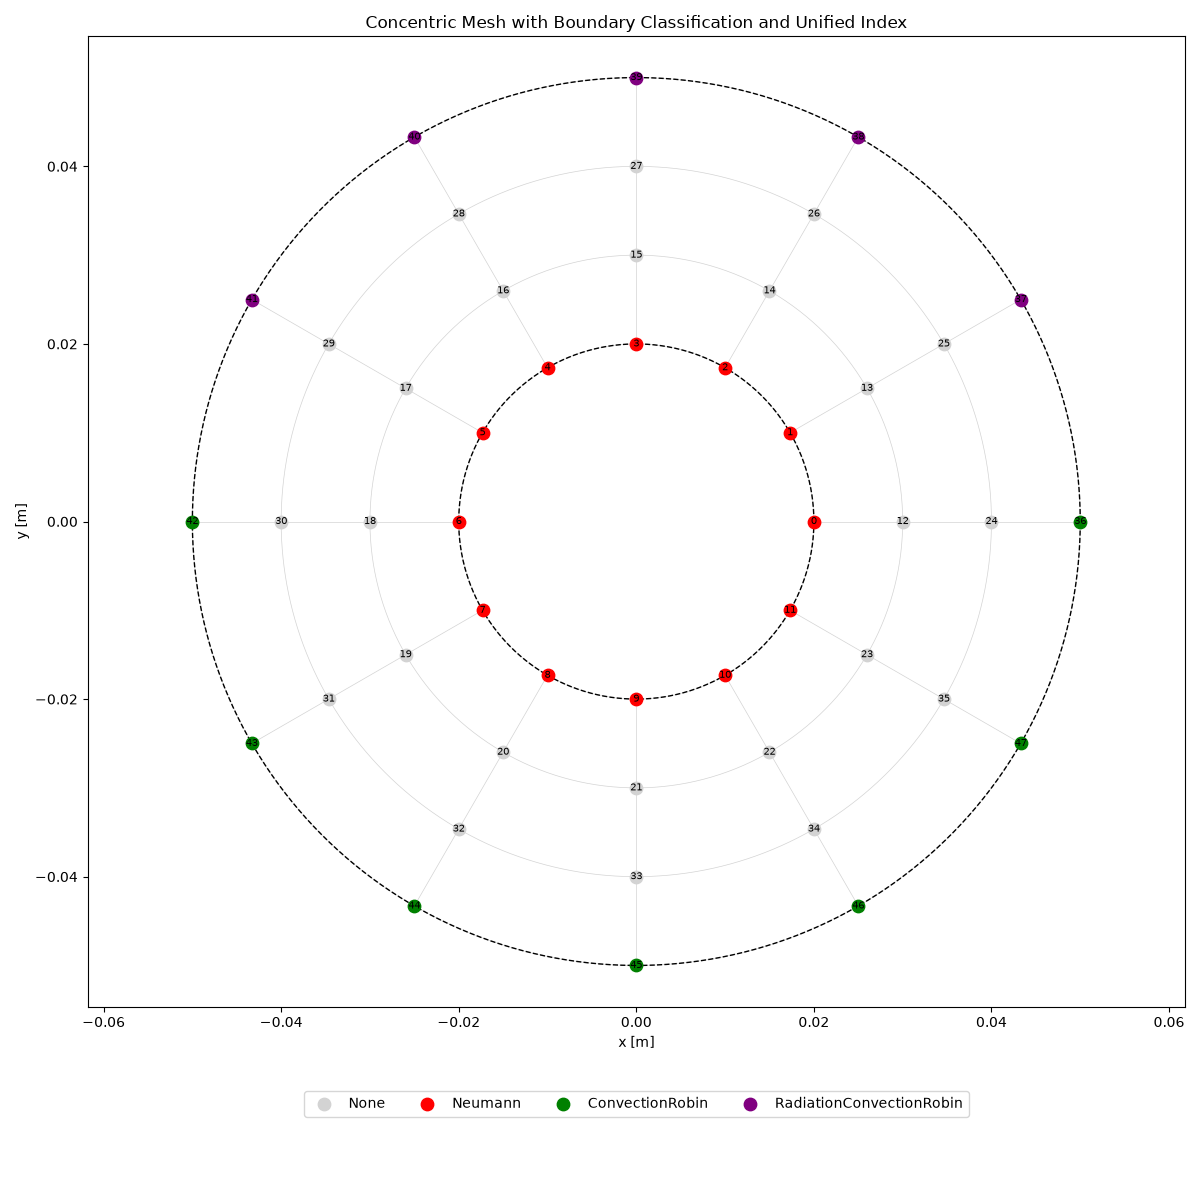

In [6]:
def PlotMeshValidation(mesh, colorMap):
    plt.figure(figsize=(12, 12))
    theta = np.linspace(0, 2 * np.pi, 1000)

    for radius in mesh.nRadii:
        plt.plot(radius * np.cos(theta), radius * np.sin(theta), color='lightgrey', linewidth=0.5, zorder=0)

    for angle in mesh.nAngles:
        plt.plot([mesh.innerRadius * np.cos(angle), mesh.outerRadius * np.cos(angle)], [mesh.innerRadius * np.sin(angle), mesh.outerRadius * np.sin(angle)], color='lightgrey', linewidth=0.5, zorder=0)

    plt.plot(mesh.innerRadius * np.cos(theta), mesh.innerRadius * np.sin(theta), 'k--', linewidth=1, zorder=1)
    plt.plot(mesh.outerRadius * np.cos(theta), mesh.outerRadius * np.sin(theta), 'k--', linewidth=1, zorder=1)

    for point in mesh.pointMap.values():
        radius = mesh.nRadii[point.radialIndex]
        angle = mesh.nAngles[point.angularIndex]
        x = radius * np.cos(angle)
        y = radius * np.sin(angle)
        plt.scatter(x, y, color=colorMap.getColor(point.boundaryType), s=80, zorder=2)
        plt.text(x, y, str(point.unifiedIndex), fontsize=7, ha='center', va='center', zorder=3)

    for boundaryType in boundaryConditions:
        plt.scatter([], [], color=colorMap.getColor(boundaryType), s=80, label=boundaryType)

    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title("Concentric Mesh with Boundary Classification and Unified Index")
    plt.axis("equal")
    plt.grid(False)
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, fontsize=10, frameon=True)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()

PlotMeshValidation(mesh1, colorMap)

> ## **Defining Finite Difference Equations for Discretized Mesh**

## For Internal Node

Define:

$$
\alpha_i = \frac{\Delta r}{2r_i}
$$

$$
\beta_i = \frac{\Delta r^2}{r_i^2\Delta\theta^2}
$$

Then the finite difference approximation using central differences is:

$$
(1-\alpha_i)T_{prevRadPt}
+
(1+\alpha_i)T_{nxtRadPt}
+
\beta_iT_{prevAziPt}
+
\beta_iT_{nextAziPt}
-
2(1+\beta_i)T_{currentPt}
=
0
$$

---

## For Inner Neumann Boundary

For the insulated inner boundary:

$$
\frac{\partial T}{\partial r}=0
$$

Using the image point method:

$$
T_{prevRadPt}=T_{nxtRadPt}
$$

Then the finite difference equation becomes:

$$
2T_{nxtRadPt}
+
\beta_iT_{prevAziPt}
+
\beta_iT_{nextAziPt}
-
2(1+\beta_i)T_{currentPt}
=
0
$$

---

In [7]:
def Alpha(mesh, unifiedPointIndex):
    pointMapping = mesh.pointMap[unifiedPointIndex]
    radius = mesh.nRadii[pointMapping.radialIndex]
    alphaValue = mesh.deltaR / (2 * radius)
    return alphaValue

def Beta(mesh, unifiedPointIndex):
    pointMapping = mesh.pointMap[unifiedPointIndex]
    radius = mesh.nRadii[pointMapping.radialIndex]
    betaValue = (mesh.deltaR**2) / ((mesh.deltaTheta**2) * (radius**2))
    return betaValue

def InternalNodeFiniteDifference(mesh, unifiedPointIndex):
    if(not mesh.pointMap[unifiedPointIndex].isBoundary):       
        pointMapping = mesh.pointMap[unifiedPointIndex]
        equationCoeffs = np.zeros(mesh.numElements)
        betaValue = Beta(mesh, unifiedPointIndex)
        alphaValue = Alpha(mesh, unifiedPointIndex)
        pointMapping.pointCoefficient = -2 * (1 + betaValue)
        pointMapping.nextRadialUnifiedCoefficient = (1 + alphaValue)
        pointMapping.prevRadialUnifiedCoefficient = (1 - alphaValue)
        pointMapping.nextAzimuthalUnifiedCoefficient = betaValue
        pointMapping.prevAzimuthalUnifiedCoefficient = betaValue
        equationCoeffs[pointMapping.unifiedIndex] = pointMapping.pointCoefficient
        equationCoeffs[pointMapping.nextRadialUnifiedIndex] = pointMapping.nextRadialUnifiedCoefficient
        equationCoeffs[pointMapping.prevRadialUnifiedIndex] = pointMapping.prevRadialUnifiedCoefficient
        equationCoeffs[pointMapping.nextAzimuthalUnifiedIndex] = pointMapping.nextAzimuthalUnifiedCoefficient
        equationCoeffs[pointMapping.prevAzimuthalUnifiedIndex] = pointMapping.prevAzimuthalUnifiedCoefficient
        rhsValue = 0
    return [equationCoeffs, rhsValue]

def InnerNeumannFiniteDifference(mesh, unifiedPointIndex):
    pointMapping = mesh.pointMap[unifiedPointIndex]
    equationCoeffs = np.zeros(mesh.numElements)
    betaValue = Beta(mesh, unifiedPointIndex)

    pointMapping.pointCoefficient = -2 * (1 + betaValue)
    pointMapping.nextRadialUnifiedCoefficient = 2
    pointMapping.nextAzimuthalUnifiedCoefficient = betaValue
    pointMapping.prevAzimuthalUnifiedCoefficient = betaValue

    equationCoeffs[pointMapping.unifiedIndex] = pointMapping.pointCoefficient
    equationCoeffs[pointMapping.nextRadialUnifiedIndex] = pointMapping.nextRadialUnifiedCoefficient
    equationCoeffs[pointMapping.nextAzimuthalUnifiedIndex] = pointMapping.nextAzimuthalUnifiedCoefficient
    equationCoeffs[pointMapping.prevAzimuthalUnifiedIndex] = pointMapping.prevAzimuthalUnifiedCoefficient

    rhsValue = 0

    return [equationCoeffs, rhsValue]


## For Outer Convective Robin Boundary

Define:

$$
\alpha_i = \frac{\Delta r}{2r_i}
$$

$$
\beta_i = \frac{\Delta r^2}{r_i^2\Delta\theta^2}
$$

$$
\gamma = \frac{h\Delta r}{k}
$$

At the outer boundary:

$$
-k\frac{\partial T}{\partial r}
=
h(T-T_\infty)
$$

Using the image point method:

$$
T_{nxtRadPt}
=
T_{prevRadPt}
-
2\gamma(T_{currentPt}-T_\infty)
$$

Then the finite difference equation becomes:

$$
2T_{prevRadPt}
+
\beta_iT_{prevAziPt}
+
\beta_iT_{nextAziPt}
-
2\left[(1+\beta_i)+(1+\alpha_i)\gamma\right]T_{currentPt}
=
-2(1+\alpha_i)\gamma T_\infty
$$

---

## For Combined Convective-Radiative Robin Boundary

The outer boundary condition is:
$$
-k\left.\frac{\partial T}{\partial r}\right|_{r=R_o}
=
h(T_{currentPt}-T_\infty)-q''(\theta)
$$

where the incident irradiation is:

$$
q''(\theta)=
\begin{cases}
q_0''\sin\theta, & 0<\theta<\pi,\\
0, & \pi<\theta<2\pi.
\end{cases}
$$

Using the image point method:

$$
-k\frac{T_{nxtRadPt}-T_{prevRadPt}}{2\Delta r}
=
h(T_{currentPt}-T_\infty)-q''(\theta)
$$

Therefore:

$$
T_{nxtRadPt}
=
T_{prevRadPt}
-
2\gamma(T_{currentPt}-T_\infty)
+
\frac{2\Delta r}{k}q''(\theta)
$$

Then the finite difference equation becomes:

$$
2T_{prevRadPt}
+
\beta_iT_{prevAziPt}
+
\beta_iT_{nextAziPt}
-
2\left[(1+\beta_i)+(1+\alpha_i)\gamma\right]T_{currentPt}
=
-2(1+\alpha_i)
\left[
\gamma T_\infty
+
\frac{\Delta r}{k}q''(\theta)
\right]
$$

### For the irradiated half, $0<\theta<\pi$

$$
2T_{prevRadPt}
+
\beta_iT_{prevAziPt}
+
\beta_iT_{nextAziPt}
-
2\left[(1+\beta_i)+(1+\alpha_i)\gamma\right]T_{currentPt}
=
-2(1+\alpha_i)
\left[
\gamma T_\infty
+
\frac{\Delta r}{k}q_0''\sin\theta
\right]
$$

### For the convective-only half, $\pi<\theta<2\pi$

$$
2T_{prevRadPt}
+
\beta_iT_{prevAziPt}
+
\beta_iT_{nextAziPt}
-
2\left[(1+\beta_i)+(1+\alpha_i)\gamma\right]T_{currentPt}
=
-2(1+\alpha_i)\gamma T_\infty
$$

---

In [8]:
def Gamma(mesh):
    gammaValue = (convectionCoefficient * mesh.deltaR) / (thermalConductivity)
    return gammaValue

def OuterConvectionRobinFiniteDifference(mesh, unifiedPointIndex):
    pointMapping = mesh.pointMap[unifiedPointIndex]
    equationCoeffs = np.zeros(mesh.numElements)
    betaValue = Beta(mesh, unifiedPointIndex)
    alphaValue = Alpha(mesh, unifiedPointIndex)
    gammaValue = (convectionCoefficient * mesh.deltaR) / thermalConductivity
    pointMapping.pointCoefficient = -2 * ((1 + betaValue) + (1 + alphaValue) * gammaValue)
    pointMapping.prevRadialUnifiedCoefficient = 2
    pointMapping.nextAzimuthalUnifiedCoefficient = betaValue
    pointMapping.prevAzimuthalUnifiedCoefficient = betaValue
    equationCoeffs[pointMapping.unifiedIndex] = pointMapping.pointCoefficient
    equationCoeffs[pointMapping.prevRadialUnifiedIndex] = pointMapping.prevRadialUnifiedCoefficient
    equationCoeffs[pointMapping.nextAzimuthalUnifiedIndex] = pointMapping.nextAzimuthalUnifiedCoefficient
    equationCoeffs[pointMapping.prevAzimuthalUnifiedIndex] = pointMapping.prevAzimuthalUnifiedCoefficient
    rhsValue = -2 * (1 + alphaValue) * gammaValue * ambientTemperature
    return [equationCoeffs, rhsValue]

def RadiationConvectionRobinFiniteDifference(mesh, unifiedPointIndex):
    pointMapping = mesh.pointMap[unifiedPointIndex]
    equationCoeffs = np.zeros(mesh.numElements)
    betaValue = Beta(mesh, unifiedPointIndex)
    alphaValue = Alpha(mesh, unifiedPointIndex)
    gammaValue = (convectionCoefficient * mesh.deltaR) / thermalConductivity
    theta = mesh.nAngles[pointMapping.angularIndex]

    if theta > 0 and theta < np.pi:
        incidentHeatFlux = heatFluxAmplitude * np.sin(theta)
    else:
        incidentHeatFlux = 0

    pointMapping.pointCoefficient = -2 * ((1 + betaValue) + (1 + alphaValue) * gammaValue)
    pointMapping.prevRadialUnifiedCoefficient = 2
    pointMapping.nextAzimuthalUnifiedCoefficient = betaValue
    pointMapping.prevAzimuthalUnifiedCoefficient = betaValue

    equationCoeffs[pointMapping.unifiedIndex] = pointMapping.pointCoefficient
    equationCoeffs[pointMapping.prevRadialUnifiedIndex] = pointMapping.prevRadialUnifiedCoefficient
    equationCoeffs[pointMapping.nextAzimuthalUnifiedIndex] = pointMapping.nextAzimuthalUnifiedCoefficient
    equationCoeffs[pointMapping.prevAzimuthalUnifiedIndex] = pointMapping.prevAzimuthalUnifiedCoefficient

    rhsValue = -2 * (1 + alphaValue) * (gammaValue * ambientTemperature + (mesh1.deltaR / thermalConductivity) * incidentHeatFlux)

    return [equationCoeffs, rhsValue]

> ## **Matrix Setup**

In [9]:
outputSpaceVector = np.zeros((mesh1.numElements, 1))
systemMatrix = np.zeros((mesh1.numElements, mesh1.numElements))
result = []

for unifiedPointIndex in range(mesh1.numElements):
    if not mesh1.pointMap[unifiedPointIndex].isBoundary:
        result =  InternalNodeFiniteDifference(mesh1, unifiedPointIndex)
    elif mesh1.pointMap[unifiedPointIndex].boundaryType == 'Neumann':
        result = InnerNeumannFiniteDifference(mesh1, unifiedPointIndex)
    elif mesh1.pointMap[unifiedPointIndex].boundaryType == 'ConvectionRobin':
        result = OuterConvectionRobinFiniteDifference(mesh1, unifiedPointIndex)
    elif mesh1.pointMap[unifiedPointIndex].boundaryType == 'RadiationConvectionRobin':
        result = RadiationConvectionRobinFiniteDifference(mesh1, unifiedPointIndex)
    systemMatrix[unifiedPointIndex] = result[0]
    outputSpaceVector[unifiedPointIndex, 0] = result[1]


> ## Solving the System - LU Decomposition

                                       POLAR FINITE DIFFERENCE SOLVER COMPARISON                                        

------------------------------------------------------------------------------------------------------------------------
MESH GENERATION
------------------------------------------------------------------------------------------------------------------------
Radial steps                                       : 10
Angular steps                                      : 50
Radial grid points                                 : 11
Angular grid points                                : 50
Total unknowns                                     : 550
Radial spacing, deltaR                             : 0.0030000000 m
Angular spacing, deltaTheta                        : 0.1256637061 rad
Internal nodes                                     : 450
Inner Neumann nodes                                : 50
Outer convection nodes                             : 26
Outer convection + irradiation n

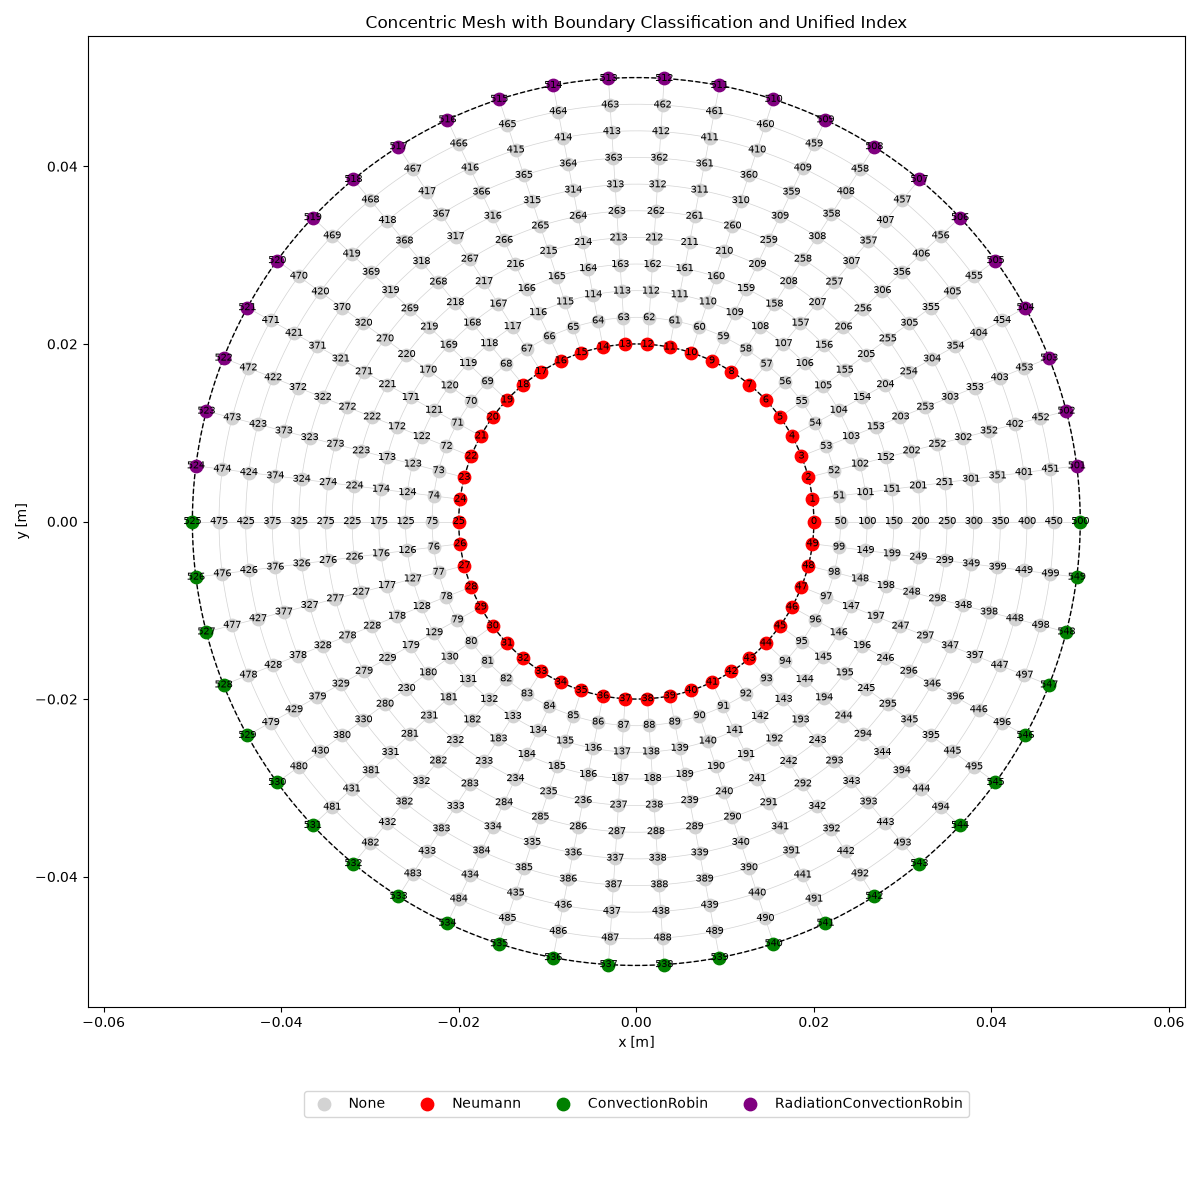

Mesh validation plots generated                    : 1
Mesh validation wall time                          : 0.985057 s

------------------------------------------------------------------------------------------------------------------------
SYSTEM MATRIX ASSEMBLY
------------------------------------------------------------------------------------------------------------------------
System matrix dimensions                           : (550, 550)
RHS vector dimensions                              : (550,)
Total matrix coefficients                          : 302,500
Non-zero matrix coefficients                       : 2,650
Matrix sparsity                                    : 99.123967 %
System matrix storage                              : 2.307892 MB
RHS vector storage                                 : 0.004196 MB
Matrix assembly CPU time                           : 0.001654 s
Matrix assembly wall time                          : 0.001326 s

-----------------------------------------------

In [10]:
def SolveAndComparePolarSystem(radialSteps=10, angularSteps=50, tolerance=1e-10, maxIterations=250000, sorValues=(1.2, 1.5, 1.8), outputDirectory="../../Dumps/Problem8"):
    import io
    import time
    import psutil
    from pathlib import Path
    from collections import Counter
    from contextlib import redirect_stdout
    from scipy.linalg import lu_factor, lu_solve, solve_triangular

    outputPath = Path(outputDirectory)
    outputPath.mkdir(parents=True, exist_ok=True)

    processInformation = psutil.Process()
    initialMemory = processInformation.memory_info().rss / (1024 ** 2)

    print("=" * 120)
    print(f"{'POLAR FINITE DIFFERENCE SOLVER COMPARISON':^120}")
    print("=" * 120)

    print("\n" + "-" * 120)
    print("MESH GENERATION")
    print("-" * 120)

    meshWallStart = time.perf_counter()
    meshCPUStart = time.process_time()

    mesh = ConcentricMesh(innerRadius, outerRadius, radialSteps, angularSteps)

    with redirect_stdout(io.StringIO()):
        ComputePointMapping(mesh)

    meshCPUTime = time.process_time() - meshCPUStart
    meshWallTime = time.perf_counter() - meshWallStart

    boundaryCounts = Counter(pointMapping.boundaryType for pointMapping in mesh.pointMap.values())

    print(f"{'Radial steps':<50} : {mesh.radialSteps}")
    print(f"{'Angular steps':<50} : {mesh.angularSteps}")
    print(f"{'Radial grid points':<50} : {mesh.radialSteps + 1}")
    print(f"{'Angular grid points':<50} : {mesh.angularSteps}")
    print(f"{'Total unknowns':<50} : {mesh.numElements}")
    print(f"{'Radial spacing, deltaR':<50} : {mesh.deltaR:.10f} m")
    print(f"{'Angular spacing, deltaTheta':<50} : {mesh.deltaTheta:.10f} rad")
    print(f"{'Internal nodes':<50} : {boundaryCounts.get('None', 0)}")
    print(f"{'Inner Neumann nodes':<50} : {boundaryCounts.get('Neumann', 0)}")
    print(f"{'Outer convection nodes':<50} : {boundaryCounts.get('ConvectionRobin', 0)}")
    print(f"{'Outer convection + irradiation nodes':<50} : {boundaryCounts.get('RadiationConvectionRobin', 0)}")
    print(f"{'Mesh generation CPU time':<50} : {meshCPUTime:.6f} s")
    print(f"{'Mesh generation wall time':<50} : {meshWallTime:.6f} s")

    print("\n" + "-" * 120)
    print("MESH VALIDATION")
    print("-" * 120)

    validationWallStart = time.perf_counter()
    PlotMeshValidation(mesh, colorMap)
    validationWallTime = time.perf_counter() - validationWallStart

    print(f"{'Mesh validation plots generated':<50} : 1")
    print(f"{'Mesh validation wall time':<50} : {validationWallTime:.6f} s")

    print("\n" + "-" * 120)
    print("SYSTEM MATRIX ASSEMBLY")
    print("-" * 120)

    assemblyWallStart = time.perf_counter()
    assemblyCPUStart = time.process_time()

    systemMatrix = np.zeros((mesh.numElements, mesh.numElements))
    rhsVector = np.zeros(mesh.numElements)

    for unifiedPointIndex in range(mesh.numElements):
        pointMapping = mesh.pointMap[unifiedPointIndex]

        if not pointMapping.isBoundary:
            finiteDifferenceResult = InternalNodeFiniteDifference(mesh, unifiedPointIndex)
        elif pointMapping.boundaryType == 'Neumann':
            finiteDifferenceResult = InnerNeumannFiniteDifference(mesh, unifiedPointIndex)
        elif pointMapping.boundaryType == 'ConvectionRobin':
            finiteDifferenceResult = OuterConvectionRobinFiniteDifference(mesh, unifiedPointIndex)
        elif pointMapping.boundaryType == 'RadiationConvectionRobin':
            finiteDifferenceResult = RadiationConvectionRobinFiniteDifference(mesh, unifiedPointIndex)
        else:
            raise ValueError(f"Unknown boundary type at point {unifiedPointIndex}")

        systemMatrix[unifiedPointIndex] = finiteDifferenceResult[0]
        rhsVector[unifiedPointIndex] = finiteDifferenceResult[1]

    assemblyCPUTime = time.process_time() - assemblyCPUStart
    assemblyWallTime = time.perf_counter() - assemblyWallStart

    numberOfNonZeroCoefficients = np.count_nonzero(systemMatrix)
    totalMatrixCoefficients = systemMatrix.size
    matrixSparsity = 100 * (1 - numberOfNonZeroCoefficients / totalMatrixCoefficients)
    matrixMemory = systemMatrix.nbytes / (1024 ** 2)
    rhsMemory = rhsVector.nbytes / (1024 ** 2)

    print(f"{'System matrix dimensions':<50} : {systemMatrix.shape}")
    print(f"{'RHS vector dimensions':<50} : {rhsVector.shape}")
    print(f"{'Total matrix coefficients':<50} : {totalMatrixCoefficients:,}")
    print(f"{'Non-zero matrix coefficients':<50} : {numberOfNonZeroCoefficients:,}")
    print(f"{'Matrix sparsity':<50} : {matrixSparsity:.6f} %")
    print(f"{'System matrix storage':<50} : {matrixMemory:.6f} MB")
    print(f"{'RHS vector storage':<50} : {rhsMemory:.6f} MB")
    print(f"{'Matrix assembly CPU time':<50} : {assemblyCPUTime:.6f} s")
    print(f"{'Matrix assembly wall time':<50} : {assemblyWallTime:.6f} s")

    diagonalValues = np.diag(systemMatrix).copy()

    if np.any(np.abs(diagonalValues) < 1e-14):
        raise ValueError("Zero or near-zero diagonal coefficient detected. Iterative solvers cannot proceed.")

    diagonalMatrix = np.diag(diagonalValues)
    lowerMatrix = np.tril(systemMatrix, -1)
    upperMatrix = np.triu(systemMatrix, 1)
    gaussSeidelMatrix = np.tril(systemMatrix)

    unifiedIndices = np.arange(mesh.numElements)
    radialIndices = np.array([mesh.pointMap[index].radialIndex for index in unifiedIndices])
    angularIndices = np.array([mesh.pointMap[index].angularIndex for index in unifiedIndices])
    radiusValues = mesh.nRadii[radialIndices]
    thetaValues = mesh.nAngles[angularIndices]
    xValues = radiusValues * np.cos(thetaValues)
    yValues = radiusValues * np.sin(thetaValues)

    def SaveSolutionData(fileName, solverName, solutionVector, iterations, converged, residualNorm, omega=None):
        filePath = outputPath / fileName
        solutionOutput = np.column_stack((unifiedIndices, radialIndices, angularIndices, radiusValues, thetaValues, xValues, yValues, solutionVector))

        headerLines = [
            f"Solver: {solverName}",
            f"RadialSteps: {radialSteps}",
            f"AngularSteps: {angularSteps}",
            f"DeltaR: {mesh.deltaR:.12e}",
            f"DeltaTheta: {mesh.deltaTheta:.12e}",
            f"Tolerance: {tolerance:.12e}",
            f"MaximumIterations: {maxIterations}",
            f"Iterations: {iterations}",
            f"Converged: {converged}",
            f"ResidualNorm: {residualNorm:.12e}"
        ]

        if omega is not None:
            headerLines.append(f"Omega: {omega:.6f}")

        headerLines.append("UnifiedIndex\tRadialIndex\tAngularIndex\tRadius\tTheta\tX\tY\tTemperature")

        np.savetxt(filePath, solutionOutput, delimiter="\t", header="\n".join(headerLines), comments="# ", fmt=["%d", "%d", "%d", "%.12e", "%.12e", "%.12e", "%.12e", "%.12e"])

        return filePath

    solverResults = []
    solutionVectors = {}

    print("\n" + "-" * 120)
    print("LU FACTORIZATION")
    print("-" * 120)

    luCPUStart = time.process_time()
    luWallStart = time.perf_counter()

    factorizationWallStart = time.perf_counter()
    factorizedSystemMatrix, pivotIndices = lu_factor(systemMatrix)
    factorizationWallTime = time.perf_counter() - factorizationWallStart

    solutionWallStart = time.perf_counter()
    luSolution = lu_solve((factorizedSystemMatrix, pivotIndices), rhsVector)
    luSolutionWallTime = time.perf_counter() - solutionWallStart

    luCPUTime = time.process_time() - luCPUStart
    luWallTime = time.perf_counter() - luWallStart

    luResidualNorm = np.linalg.norm(systemMatrix @ luSolution - rhsVector)

    luFilePath = SaveSolutionData("LU_Polar.txt", "LU Factorization", luSolution, 1, True, luResidualNorm)

    solutionVectors["LU"] = luSolution

    solverResults.append({
        "solver": "LU",
        "omega": None,
        "converged": True,
        "iterations": 1,
        "cpuTime": luCPUTime,
        "wallTime": luWallTime,
        "residualNorm": luResidualNorm,
        "relativeUpdate": 0,
        "minimumTemperature": np.min(luSolution),
        "maximumTemperature": np.max(luSolution),
        "meanTemperature": np.mean(luSolution),
        "filePath": luFilePath
    })

    print(f"{'LU factorization wall time':<50} : {factorizationWallTime:.6f} s")
    print(f"{'LU solution wall time':<50} : {luSolutionWallTime:.6f} s")
    print(f"{'Total LU wall time':<50} : {luWallTime:.6f} s")
    print(f"{'LU residual norm':<50} : {luResidualNorm:.6e}")
    print(f"{'Minimum temperature':<50} : {np.min(luSolution):.8f} °C")
    print(f"{'Maximum temperature':<50} : {np.max(luSolution):.8f} °C")
    print(f"{'Solution file':<50} : {luFilePath}")

    def RunIterativeSolver(solverName, fileName, omega=None):
        solutionVector = np.full(mesh.numElements, ambientTemperature, dtype=float)
        converged = False
        relativeUpdate = np.inf

        cpuStart = time.process_time()
        wallStart = time.perf_counter()

        if solverName == "GJ":
            for iteration in range(1, maxIterations + 1):
                newSolutionVector = solutionVector + (rhsVector - systemMatrix @ solutionVector) / diagonalValues
                relativeUpdate = np.max(np.abs(newSolutionVector - solutionVector)) / max(1.0, np.max(np.abs(newSolutionVector)))
                solutionVector = newSolutionVector

                if not np.all(np.isfinite(solutionVector)):
                    break

                if relativeUpdate <= tolerance:
                    converged = True
                    break

        elif solverName == "GS":
            for iteration in range(1, maxIterations + 1):
                newSolutionVector = solve_triangular(gaussSeidelMatrix, rhsVector - upperMatrix @ solutionVector, lower=True, check_finite=False)
                relativeUpdate = np.max(np.abs(newSolutionVector - solutionVector)) / max(1.0, np.max(np.abs(newSolutionVector)))
                solutionVector = newSolutionVector

                if not np.all(np.isfinite(solutionVector)):
                    break

                if relativeUpdate <= tolerance:
                    converged = True
                    break

        elif solverName == "SOR":
            sorLeftMatrix = diagonalMatrix + omega * lowerMatrix
            sorRightMatrix = omega * upperMatrix + (omega - 1) * diagonalMatrix

            for iteration in range(1, maxIterations + 1):
                newSolutionVector = solve_triangular(sorLeftMatrix, omega * rhsVector - sorRightMatrix @ solutionVector, lower=True, check_finite=False)
                relativeUpdate = np.max(np.abs(newSolutionVector - solutionVector)) / max(1.0, np.max(np.abs(newSolutionVector)))
                solutionVector = newSolutionVector

                if not np.all(np.isfinite(solutionVector)):
                    break

                if relativeUpdate <= tolerance:
                    converged = True
                    break

        else:
            raise ValueError(f"Unknown solver: {solverName}")

        cpuTime = time.process_time() - cpuStart
        wallTime = time.perf_counter() - wallStart

        residualNorm = np.linalg.norm(systemMatrix @ solutionVector - rhsVector)
        filePath = SaveSolutionData(fileName, solverName, solutionVector, iteration, converged, residualNorm, omega)

        resultName = solverName

        if omega is not None:
            resultName = f"SOR {omega:.2f}"

        solutionVectors[resultName] = solutionVector

        solverResults.append({
            "solver": resultName,
            "omega": omega,
            "converged": converged,
            "iterations": iteration,
            "cpuTime": cpuTime,
            "wallTime": wallTime,
            "residualNorm": residualNorm,
            "relativeUpdate": relativeUpdate,
            "minimumTemperature": np.min(solutionVector),
            "maximumTemperature": np.max(solutionVector),
            "meanTemperature": np.mean(solutionVector),
            "filePath": filePath
        })

        print(f"\n{resultName}")
        print(f"{'Converged':<50} : {converged}")
        print(f"{'Iterations':<50} : {iteration:,}")
        print(f"{'Final relative update':<50} : {relativeUpdate:.6e}")
        print(f"{'Residual norm':<50} : {residualNorm:.6e}")
        print(f"{'CPU time':<50} : {cpuTime:.6f} s")
        print(f"{'Wall time':<50} : {wallTime:.6f} s")
        print(f"{'Minimum temperature':<50} : {np.min(solutionVector):.8f} °C")
        print(f"{'Maximum temperature':<50} : {np.max(solutionVector):.8f} °C")
        print(f"{'Maximum difference from LU':<50} : {np.max(np.abs(solutionVector - luSolution)):.6e} °C")
        print(f"{'Solution file':<50} : {filePath}")

    print("\n" + "-" * 120)
    print("ITERATIVE SOLVERS")
    print("-" * 120)

    RunIterativeSolver("GJ", "GJ_Polar.txt")
    RunIterativeSolver("GS", "GS_Polar.txt")

    for omega in sorValues:
        omegaTag = f"{omega:.2f}".replace(".", "p")
        RunIterativeSolver("SOR", f"SOR_{omegaTag}_Polar.txt", omega)

    for result in solverResults:
        solutionVector = solutionVectors[result["solver"]]
        result["maximumDifferenceFromLU"] = np.max(np.abs(solutionVector - luSolution))
        result["rmsDifferenceFromLU"] = np.sqrt(np.mean((solutionVector - luSolution) ** 2))

    print("\n" + "=" * 120)
    print(f"{'SOLVER PERFORMANCE COMPARISON':^120}")
    print("=" * 120)

    performanceHeader = f"{'Solver':<14}{'Omega':>9}{'Converged':>12}{'Iterations':>14}{'CPU [s]':>14}{'Wall [s]':>14}{'Residual':>18}{'Rel. Update':>18}"
    performanceSeparator = "-" * len(performanceHeader)

    print(performanceHeader)
    print(performanceSeparator)

    performanceLines = [performanceHeader, performanceSeparator]

    for result in solverResults:
        omegaText = "---" if result["omega"] is None else f"{result['omega']:.2f}"
        line = f"{result['solver']:<14}{omegaText:>9}{str(result['converged']):>12}{result['iterations']:>14,d}{result['cpuTime']:>14.6f}{result['wallTime']:>14.6f}{result['residualNorm']:>18.6e}{result['relativeUpdate']:>18.6e}"
        print(line)
        performanceLines.append(line)

    print(performanceSeparator)
    performanceLines.append(performanceSeparator)

    print("\n" + "=" * 120)
    print(f"{'TEMPERATURE SOLUTION COMPARISON':^120}")
    print("=" * 120)

    solutionHeader = f"{'Solver':<14}{'Tmin [C]':>16}{'Tmax [C]':>16}{'Tmean [C]':>16}{'Max |T-TLU|':>20}{'RMS |T-TLU|':>20}"
    solutionSeparator = "-" * len(solutionHeader)

    print(solutionHeader)
    print(solutionSeparator)

    solutionLines = [solutionHeader, solutionSeparator]

    for result in solverResults:
        line = f"{result['solver']:<14}{result['minimumTemperature']:>16.8f}{result['maximumTemperature']:>16.8f}{result['meanTemperature']:>16.8f}{result['maximumDifferenceFromLU']:>20.8e}{result['rmsDifferenceFromLU']:>20.8e}"
        print(line)
        solutionLines.append(line)

    print(solutionSeparator)
    solutionLines.append(solutionSeparator)

    finalMemory = processInformation.memory_info().rss / (1024 ** 2)

    print("\n" + "-" * 120)
    print("OUTPUT FILES")
    print("-" * 120)

    for result in solverResults:
        print(f"{result['solver']:<20} : {result['filePath']}")

    comparisonFilePath = outputPath / "SolverComparison_Polar.txt"

    with open(comparisonFilePath, "w", encoding="utf-8") as comparisonFile:
        comparisonFile.write("POLAR FINITE DIFFERENCE SOLVER COMPARISON\n")
        comparisonFile.write("=" * 120 + "\n\n")
        comparisonFile.write(f"Radial steps        : {radialSteps}\n")
        comparisonFile.write(f"Angular steps       : {angularSteps}\n")
        comparisonFile.write(f"Total unknowns      : {mesh.numElements}\n")
        comparisonFile.write(f"DeltaR              : {mesh.deltaR:.12e}\n")
        comparisonFile.write(f"DeltaTheta          : {mesh.deltaTheta:.12e}\n")
        comparisonFile.write(f"Tolerance           : {tolerance:.12e}\n")
        comparisonFile.write(f"Maximum iterations  : {maxIterations}\n\n")
        comparisonFile.write("SOLVER PERFORMANCE COMPARISON\n")
        comparisonFile.write("\n".join(performanceLines))
        comparisonFile.write("\n\nTEMPERATURE SOLUTION COMPARISON\n")
        comparisonFile.write("\n".join(solutionLines))
        comparisonFile.write("\n")

    print(f"\n{'Comparison table':<20} : {comparisonFilePath}")
    print(f"{'Initial process memory':<50} : {initialMemory:.3f} MB")
    print(f"{'Final process memory':<50} : {finalMemory:.3f} MB")
    print(f"{'Net process memory change':<50} : {finalMemory - initialMemory:.3f} MB")

    print("\n" + "=" * 120)
    print(f"{'ALL SOLVERS COMPLETE':^120}")
    print("=" * 120)

    return mesh, systemMatrix, rhsVector, solutionVectors, solverResults

mesh, systemMatrix, rhsVector, solutionVectors, solverResults = SolveAndComparePolarSystem()

In [13]:
def PlotSolverTemperatureContours(mesh, solutionVectors, numberOfTerms=200):
    minimumTemperature = min(np.min(solutionVector) for solutionVector in solutionVectors.values())
    maximumTemperature = max(np.max(solutionVector) for solutionVector in solutionVectors.values())
    temperatureContourLevels = np.linspace(minimumTemperature, maximumTemperature, 31)
    thetaValues = np.append(mesh.nAngles, 2 * np.pi)
    thetaMesh, radiusMesh = np.meshgrid(thetaValues, mesh.nRadii)
    
    analyticalTemperatureField = AnalyticalTemperature(radiusMesh, thetaMesh, innerRadius, outerRadius, thermalConductivity, convectionCoefficient, ambientTemperature, heatFluxAmplitude, numberOfTerms)
    
    solverFields = {}
    errorFields = {}
    
    for solverName, solutionVector in solutionVectors.items():
        temperatureField = np.zeros((mesh.radialSteps + 1, mesh.angularSteps))
        solutionVector = np.asarray(solutionVector).flatten()
    
        for unifiedPointIndex in range(mesh.numElements):
            pointMapping = mesh.pointMap[unifiedPointIndex]
            temperatureField[pointMapping.radialIndex, pointMapping.angularIndex] = solutionVector[unifiedPointIndex]
    
        temperatureField = np.column_stack((temperatureField, temperatureField[:, 0]))
        errorField = np.abs(temperatureField - analyticalTemperatureField)
    
        solverFields[solverName] = temperatureField
        errorFields[solverName] = errorField
    
    maximumError = max(np.max(errorField) for errorField in errorFields.values())
    
    if maximumError == 0:
        maximumError = 1e-12
    
    errorContourLevels = np.linspace(0, maximumError, 31)
    
    for solverName in solutionVectors.keys():
        temperatureField = solverFields[solverName]
        errorField = errorFields[solverName]
    
        fig, axes = plt.subplots(1, 2, figsize=(18, 9), subplot_kw={'projection': 'polar'})
    
        temperatureContour = axes[0].contourf(thetaMesh, radiusMesh, temperatureField, levels=temperatureContourLevels, cmap='coolwarm')
        axes[0].contour(thetaMesh, radiusMesh, temperatureField, levels=temperatureContourLevels, colors='black', linewidths=0.4, alpha=0.4)
    
        temperatureColorBar = fig.colorbar(temperatureContour, ax=axes[0], pad=0.12, shrink=0.85)
        temperatureColorBar.set_label('Temperature [°C]')
    
        axes[0].set_theta_zero_location('E')
        axes[0].set_theta_direction(1)
        axes[0].set_ylim(0, mesh.outerRadius)
        axes[0].set_title(f'{solverName} Temperature Distribution', fontsize=14, pad=25)
        axes[0].grid(True)
    
        errorContour = axes[1].contourf(thetaMesh, radiusMesh, errorField, levels=errorContourLevels, cmap='inferno')
        axes[1].contour(thetaMesh, radiusMesh, errorField, levels=errorContourLevels, colors='black', linewidths=0.35, alpha=0.3)
    
        errorColorBar = fig.colorbar(errorContour, ax=axes[1], pad=0.12, shrink=0.85)
        errorColorBar.set_label('Absolute Temperature Error [°C]')
    
        axes[1].set_theta_zero_location('E')
        axes[1].set_theta_direction(1)
        axes[1].set_ylim(0, mesh.outerRadius)
        axes[1].set_title(f'{solverName} Absolute Error Against Analytical', fontsize=14, pad=25)
        axes[1].grid(True)
    
        fig.suptitle(f'{solverName} — Numerical Solution and Analytical Error', fontsize=17, y=0.97)
    
        fig.subplots_adjust(left=0.05, right=0.95, bottom=0.07, top=0.84, wspace=0.30)
    
        plt.show()


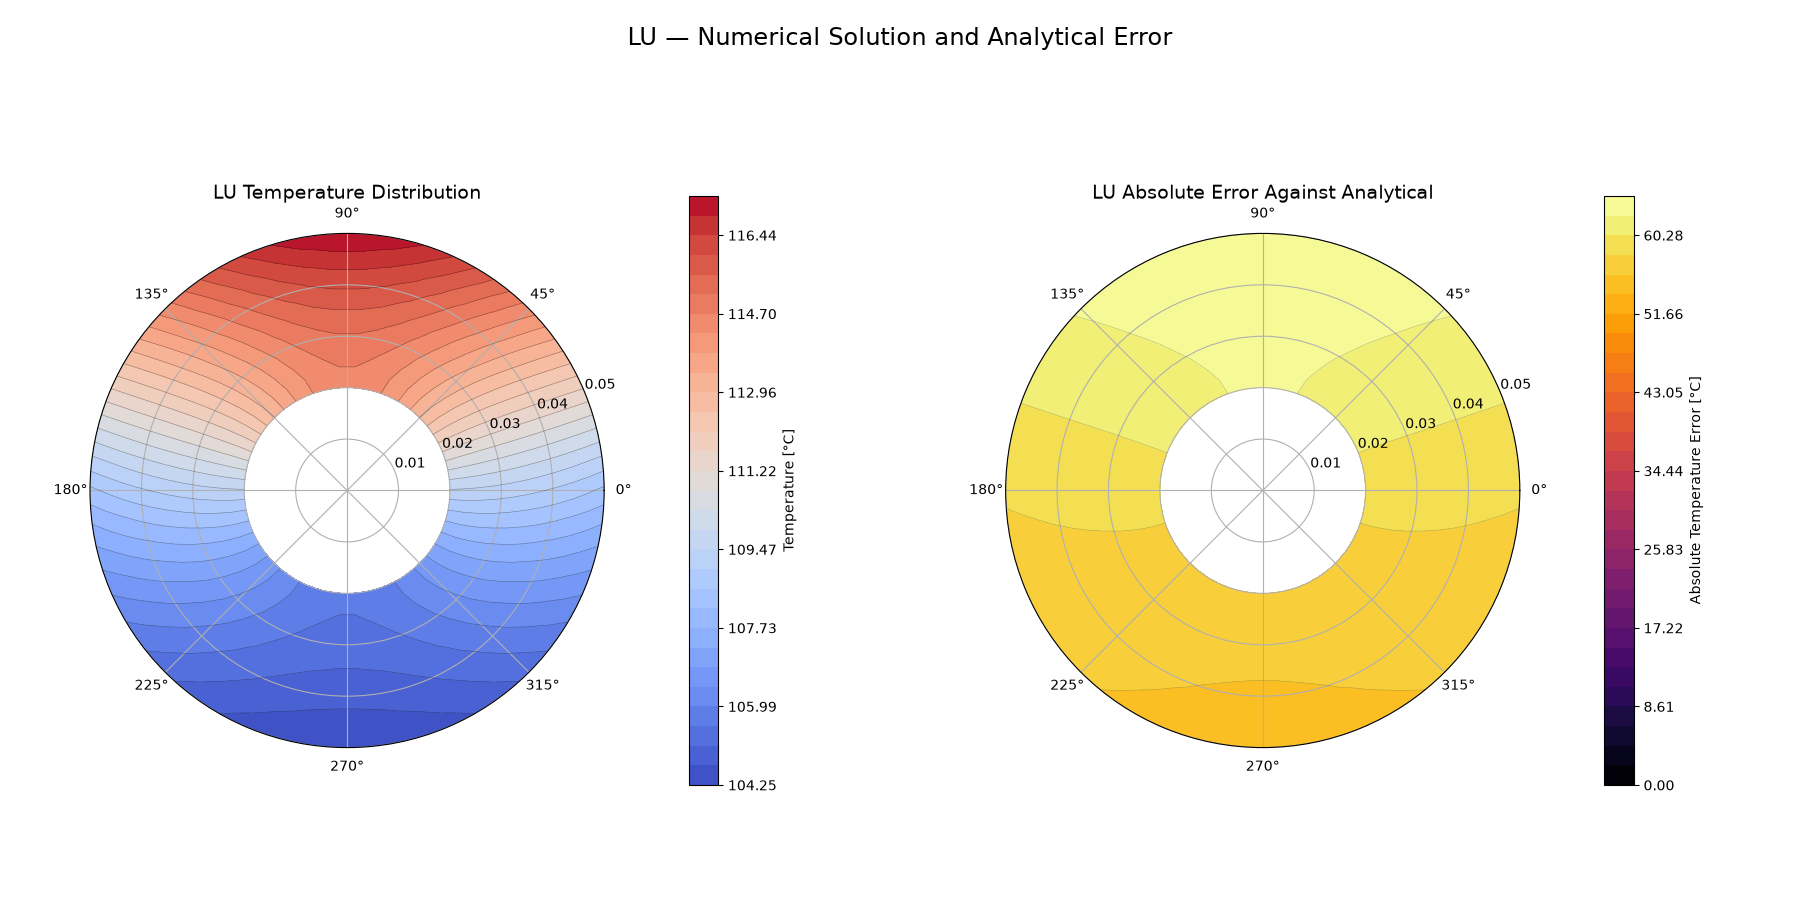

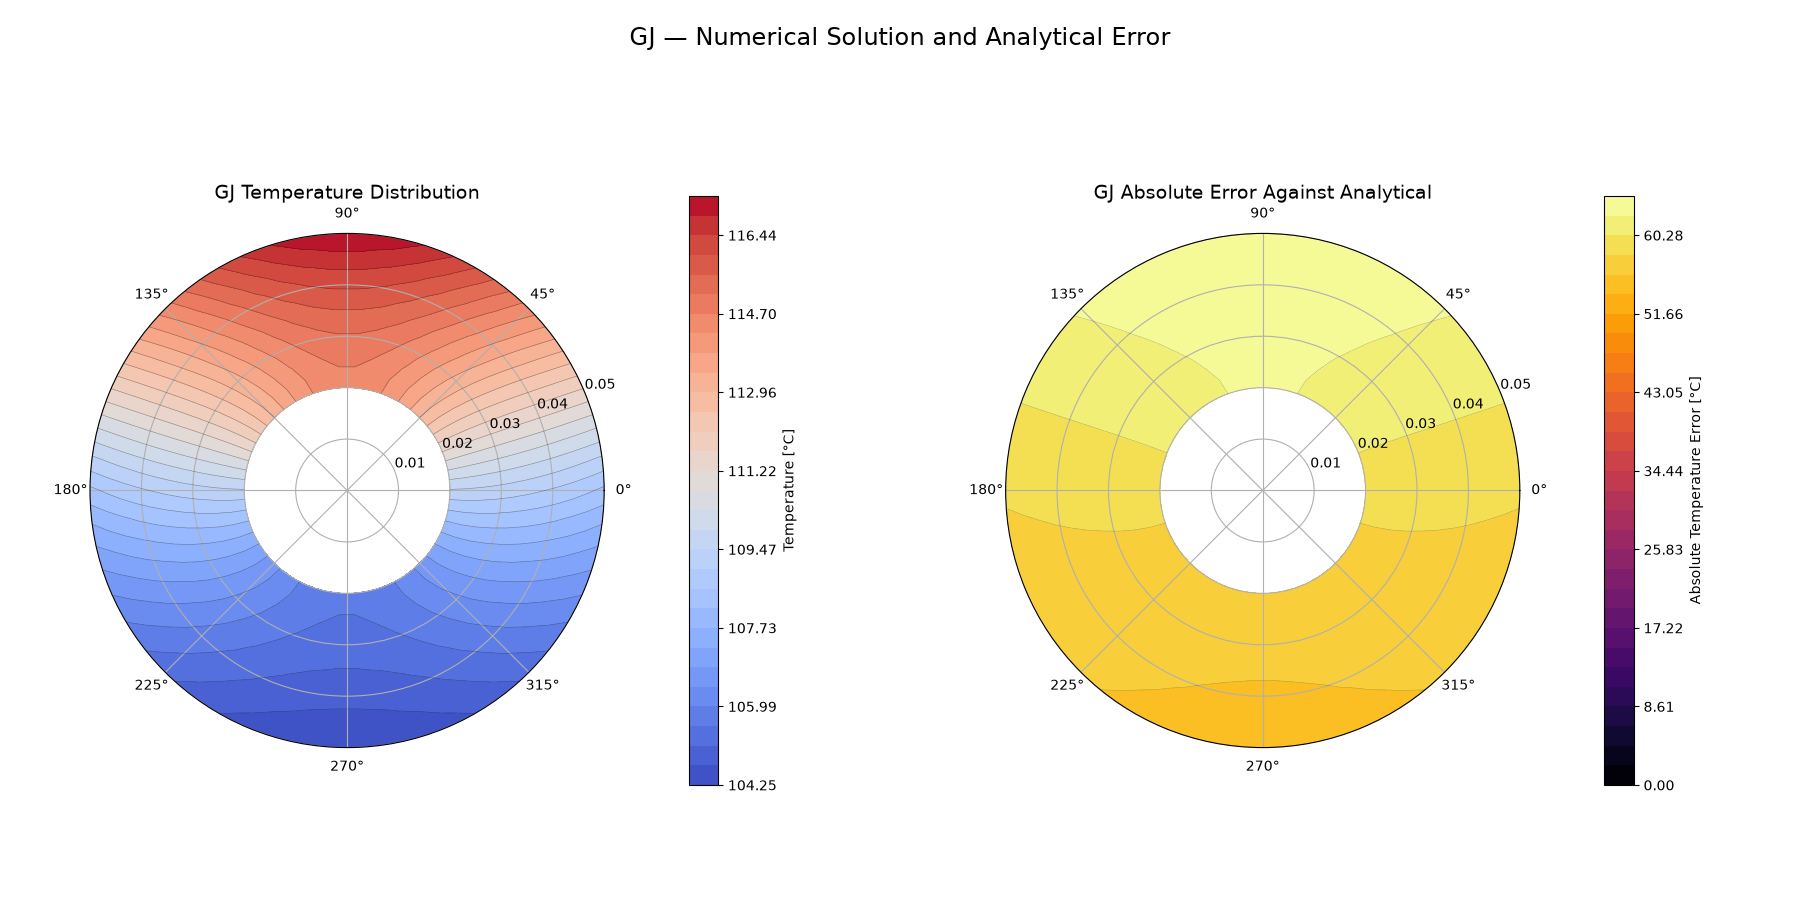

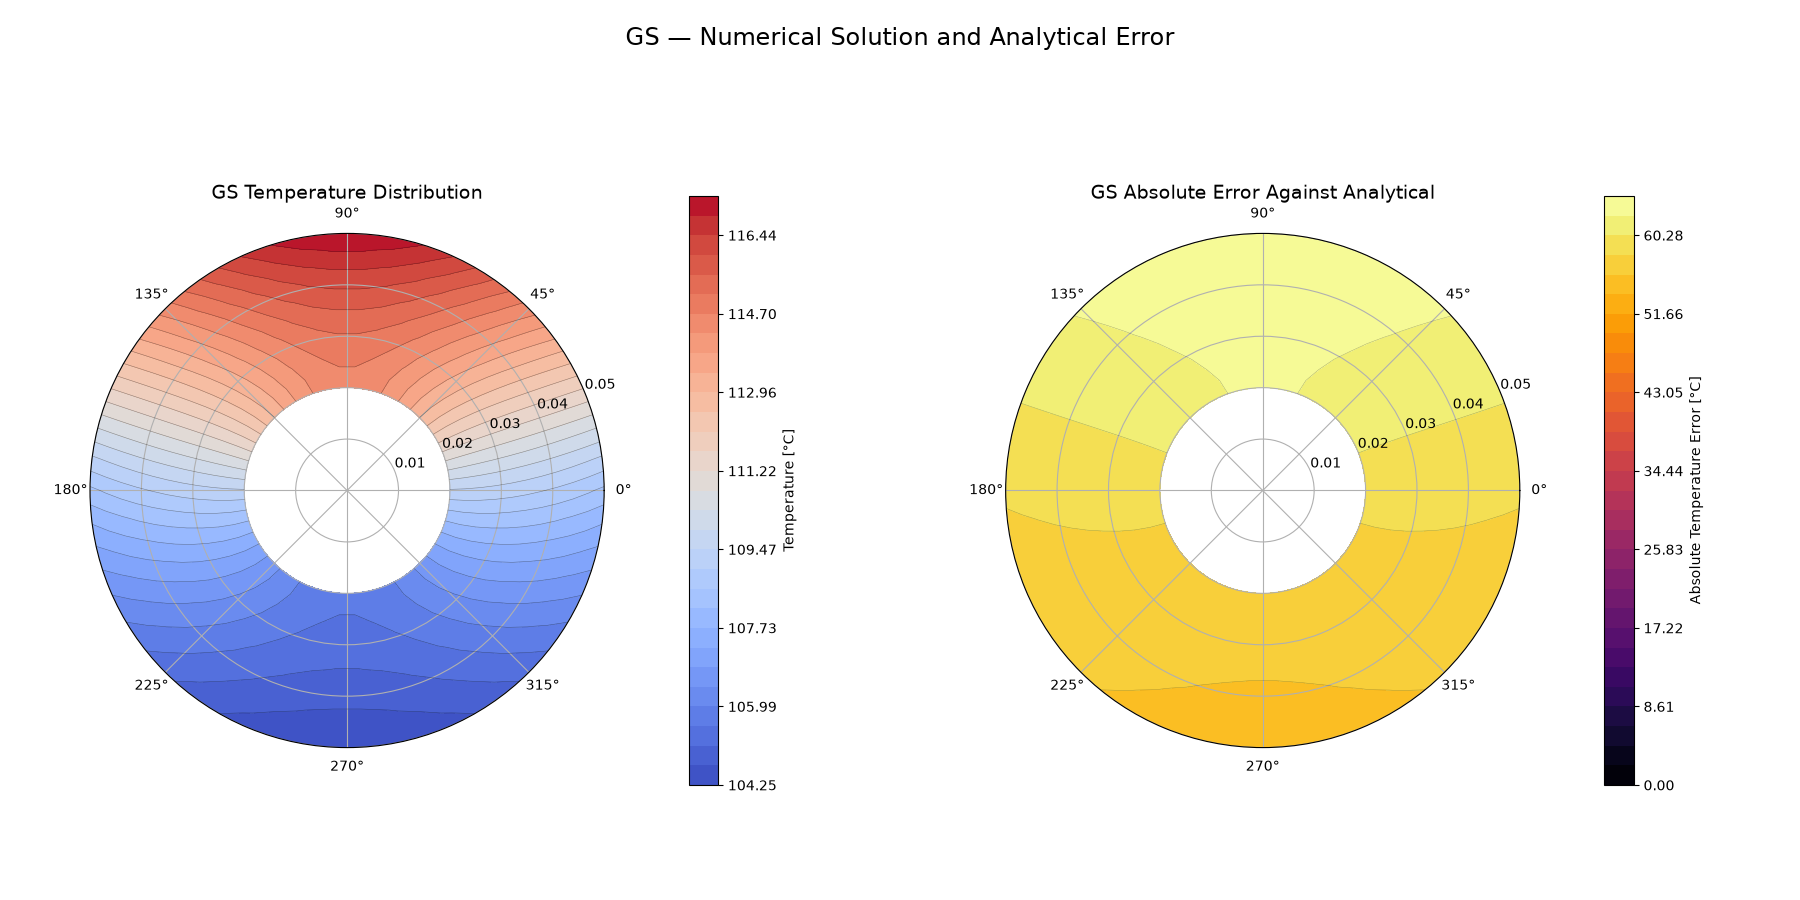

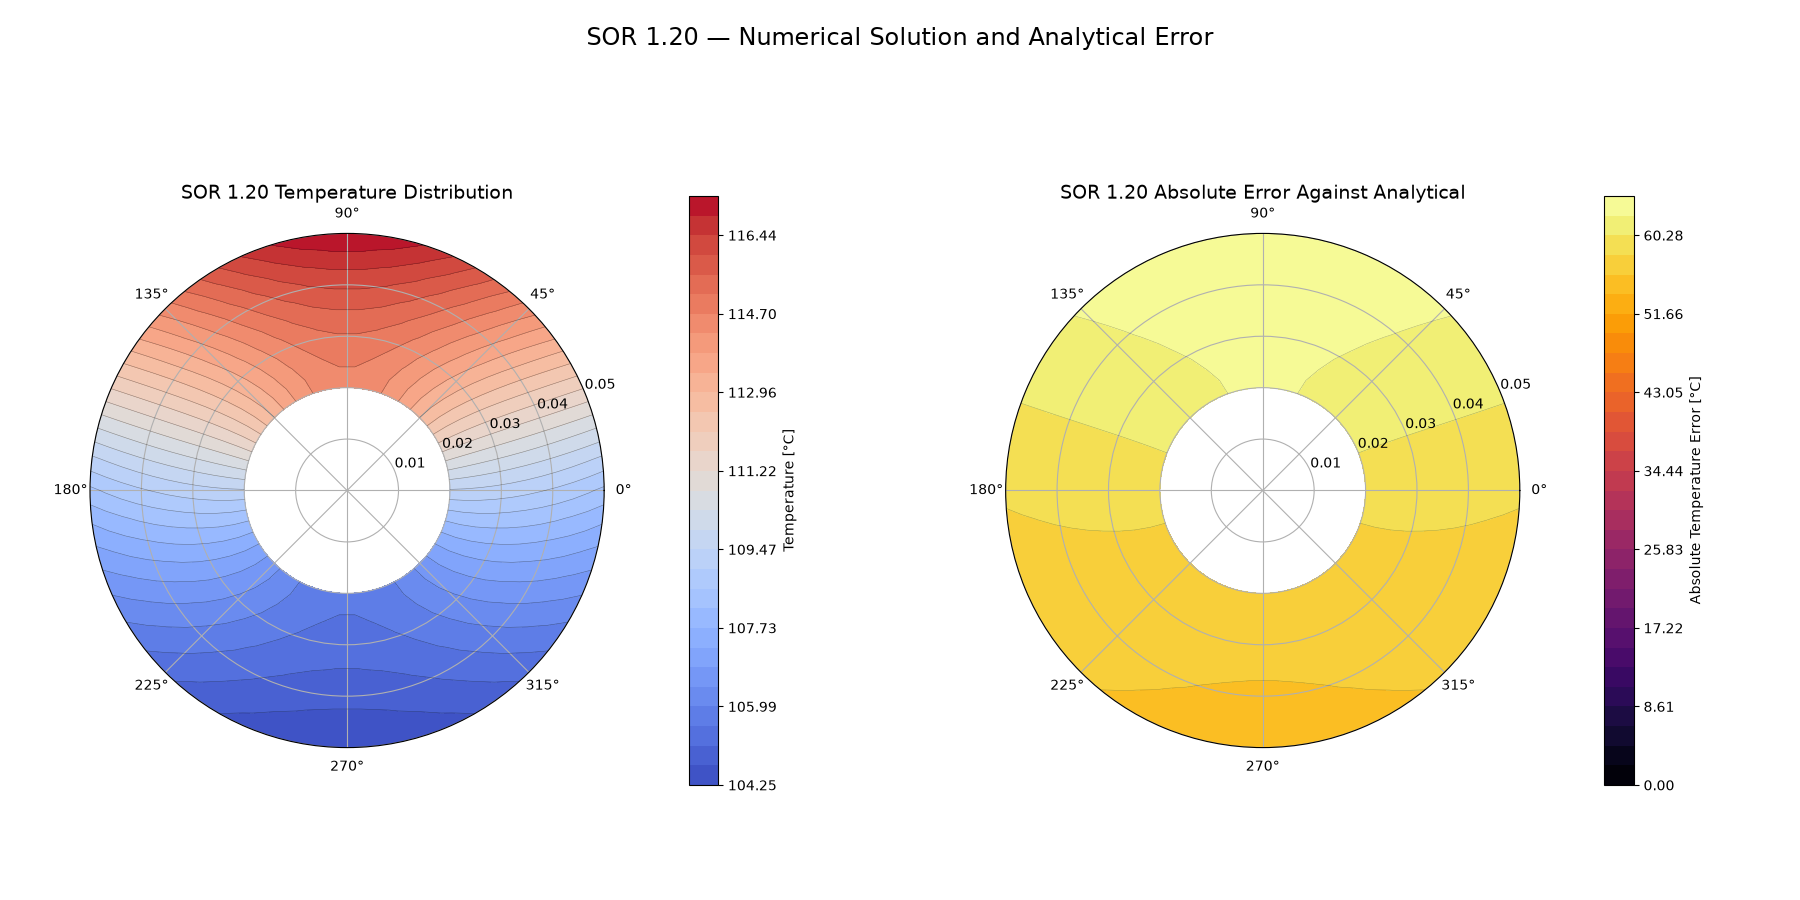

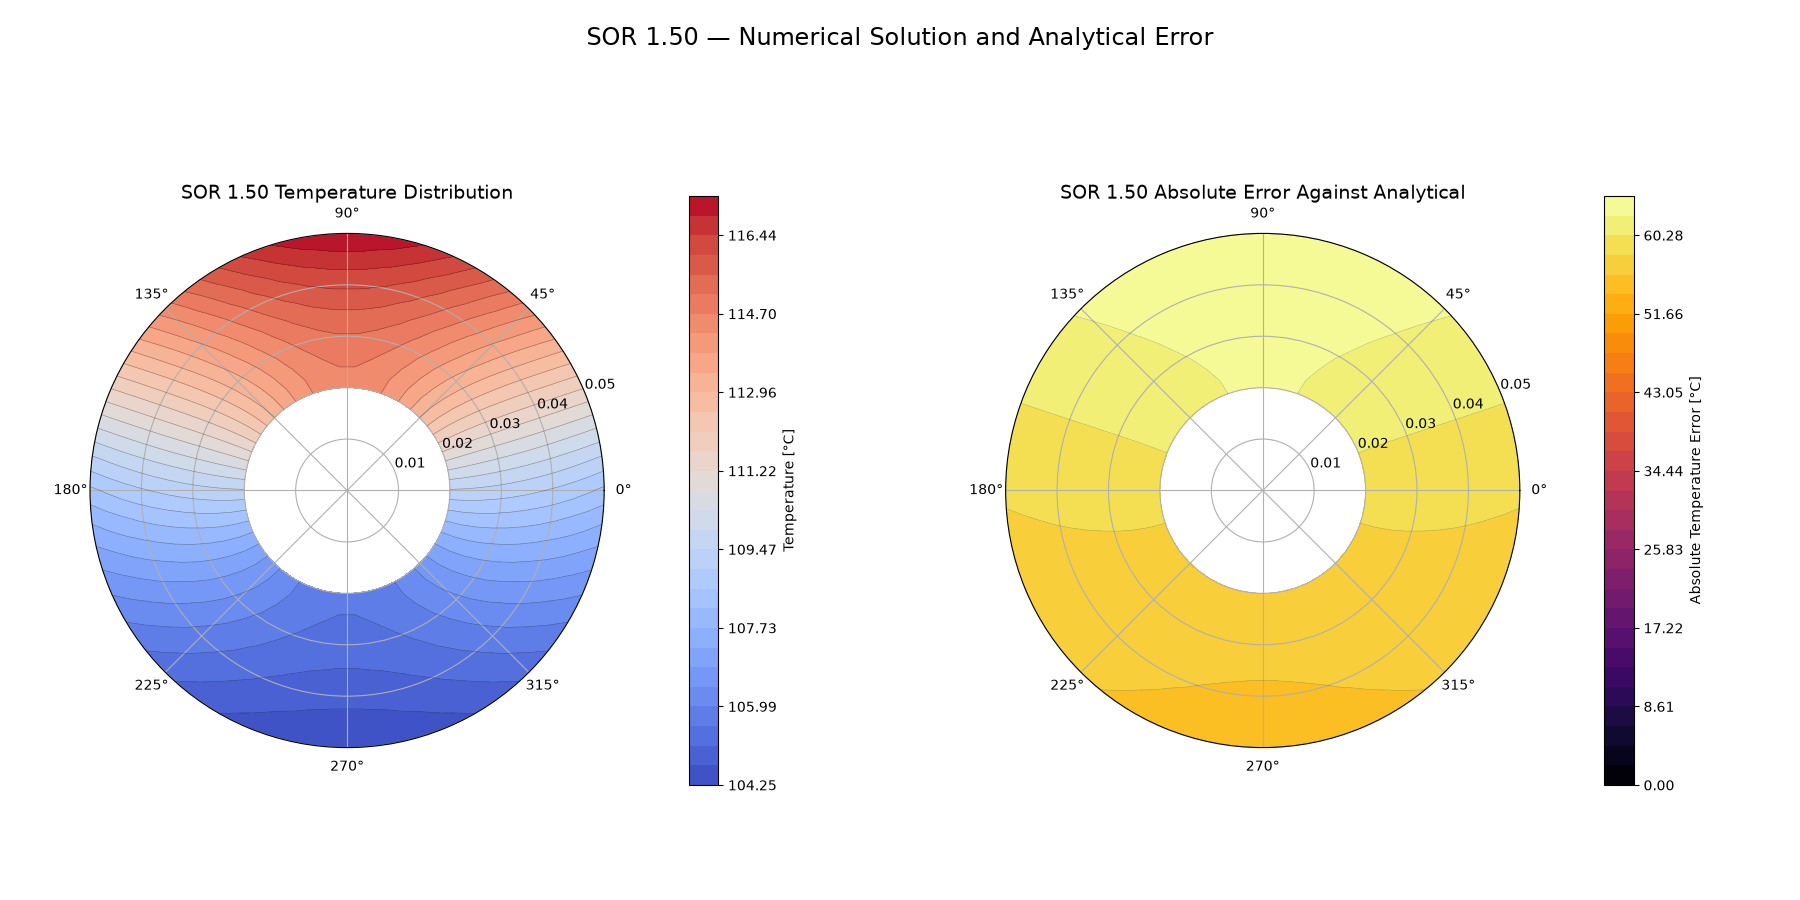

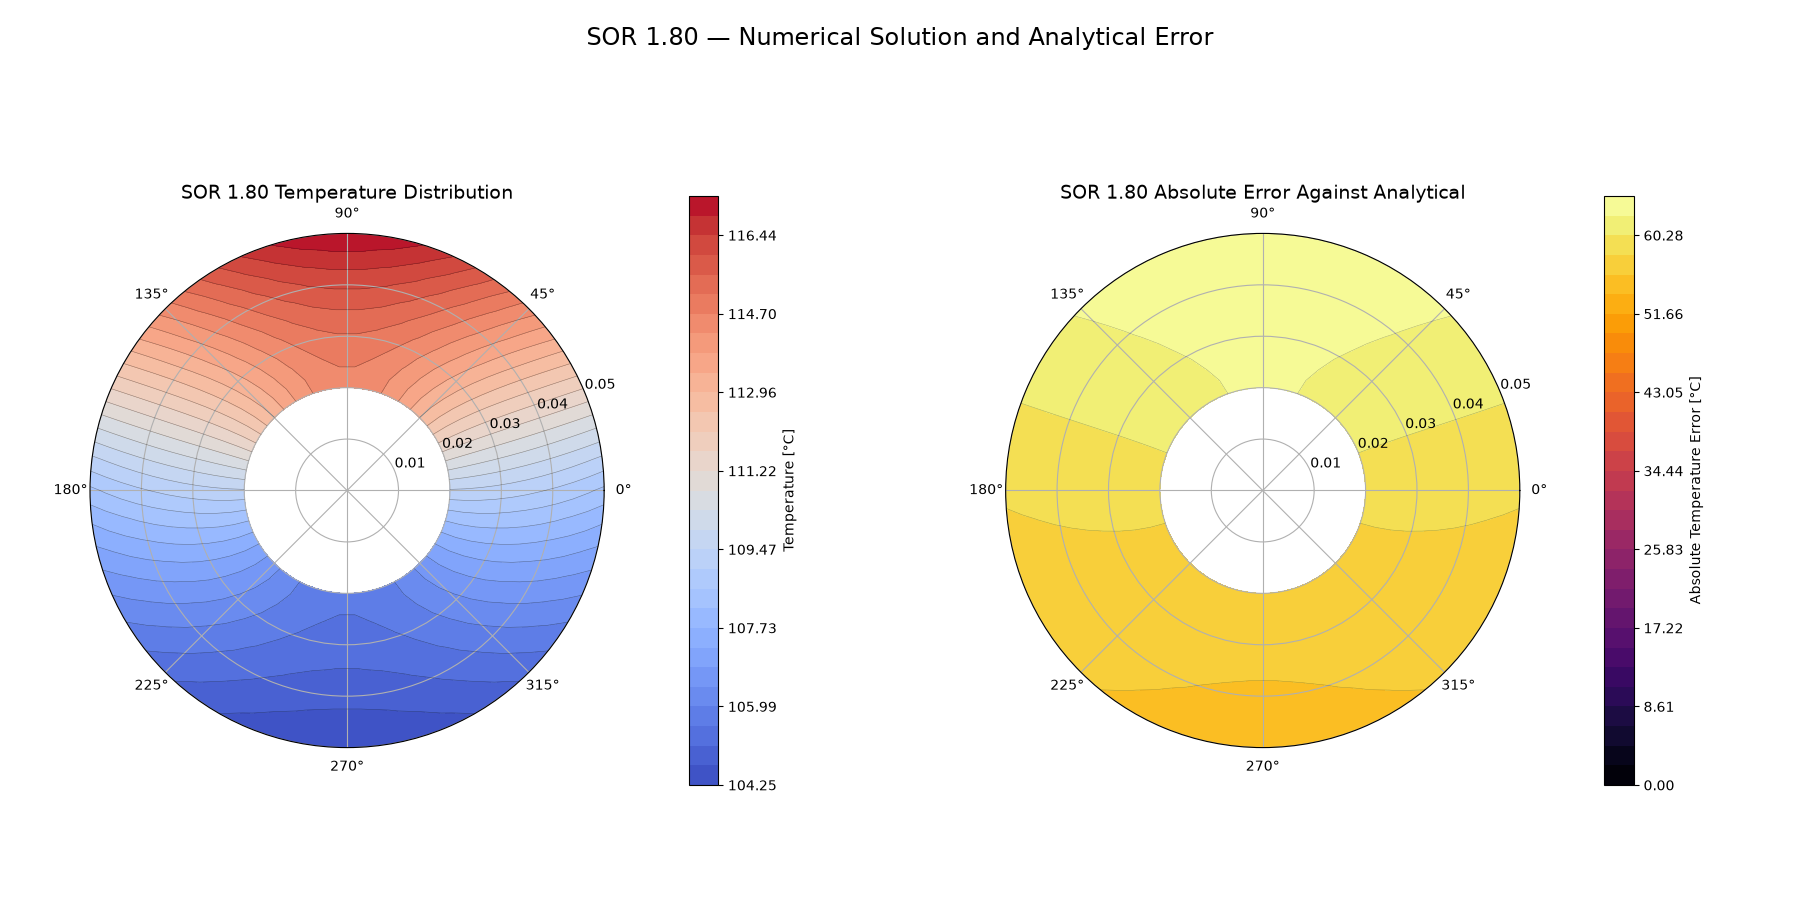

In [14]:
PlotSolverTemperatureContours(mesh, solutionVectors)